# Alinhamento discurso–partido sobre armas com o **Manacá-1B**

**Pergunta de pesquisa.** Os deputados que discursam sobre porte/posse de armas reproduzem a posição que o *seu partido* expressa em suas notícias?

Este notebook refaz a análise **sem usar os embeddings BERTimbau** já gerados. Em vez de comparar vetores, usamos o modelo de linguagem [`AIInstituteLNCC/manaca-1b-base`](https://huggingface.co/AIInstituteLNCC/manaca-1b-base) para *ler* os textos e responder perguntas explícitas, e depois transformamos as respostas em métricas empíricas interpretáveis.

## Pipeline

```
                 ┌──────────────────────────┐
 notícias ─────► │ 1. Relevância (Manacá)   │──► só notícias que de fato falam de armas
 dos partidos    └────────────┬─────────────┘
                              ▼
                 ┌──────────────────────────┐
                 │ 2. Postura (Manacá)      │──► favorável / contrário / neutro  (por notícia)
                 └────────────┬─────────────┘
                              ▼
                 ┌──────────────────────────┐
                 │ 3. Métricas do partido   │──► índice de favorabilidade, taxas, IC, posição
                 └────────────┬─────────────┘
                              │
 discursos ───►  2'. Postura (Manacá) ──► 4. Métricas do deputado ──► gap deputado × partido
 dos deputados                                                              │
                                                                            ▼
                                            ┌─────────────────────────────────────────┐
                                            │ 5. Classificadores: aderente × não      │
                                            └─────────────────────────────────────────┘
```

## Como o Manacá é usado (leia antes de rodar)

O Manacá-1B é um **modelo base** (*decoder-only*, 1,72 B de parâmetros): ele **continua textos**, não segue instruções. Por isso **não** "pedimos" a resposta. Em vez disso:

1. montamos um **prompt de completar** com instrução curta + alguns exemplos (*few-shot*) + o texto a classificar, terminando na pergunta;
2. lemos, na última posição, a **probabilidade que o modelo atribui a cada palavra-rótulo** (`Sim`/`Não`; `favorável`/`contrário`/`neutro`);
3. aplicamos **calibração contextual** (Zhao et al., 2021) para remover o viés de rótulo típico de modelos base;
4. guardamos **probabilidades**, não só a classe, o que permite medir incerteza e construir índices contínuos.

> ⚠️ O tokenizador do Manacá converte tudo para minúsculas (*lowercase por construção*, conforme o model card). Isso é tratado automaticamente pelo `AutoTokenizer` oficial; não é necessário pré-processar.

## 0. Configuração

Todos os parâmetros metodológicos ficam **nesta célula**. Cada um é explicado ao lado; mudar um valor e reexecutar basta para uma análise de sensibilidade (os resultados do modelo são **cacheados em disco**, então reexecutar é barato).

In [1]:
import os, re, json, math, time, hashlib, unicodedata, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp, softmax
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 160, "display.max_colwidth", 80)

SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------------ caminhos
ROOT = Path.cwd()
for cand in [ROOT, ROOT.parent]:
    if (cand / "content" / "noticia_partidos.jsonl").exists():
        ROOT = cand; break
SPEECHES_PATH = "/content/firearm-carry-speeches-2014-2026.jsonl"
NEWS_PATH     = "/content/noticia_partidos.jsonl"
OUT_DIR       = ROOT / "analysis_outputs_manaca"
(OUT_DIR / "cache").mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------ modelo
# "manaca" = usa o modelo de verdade (GPU recomendada).
# "dryrun" = NÃO usa modelo; gera pontuações fictícias só para testar o encanamento do notebook.
#            Resultados em dryrun NÃO têm valor científico e vão para um cache separado.
BACKEND    = os.environ.get("MANACA_BACKEND", "manaca")
MODEL_ID   = "AIInstituteLNCC/manaca-1b-base"
BATCH_SIZE = int(os.environ.get("MANACA_BATCH", 4))      # reduza se faltar memória de GPU

# ------------------------------------------------------------------ pré-processamento das notícias
NEWS_MIN_YEAR       = 2014   # notícias anteriores ficam fora das métricas (janela dos discursos: 2014-2026)
SNIPPET_WINDOW      = 400    # caracteres de contexto de cada lado de uma menção a "armas"
SNIPPET_MAX_WINDOWS = 4      # no máximo 3 trechos por notícia
SNIPPET_MAX_CHARS   = 7200   # ≈ 450 tokens: cabe com folga nos 4096 do Manacá
SPEECH_MAX_CHARS    = 7200

# ------------------------------------------------------------------ etapa 1 (relevância)
RELEVANCE_THRESHOLD = 0.45   # P(Sim) calibrada mínima para a notícia ser considerada "sobre armas"

# ------------------------------------------------------------------ etapa 2 (postura)
USE_FEW_SHOT        = None   # None = escolhe automaticamente pela validação nos discursos (seção 5.1)
SPEECH_TEXT_MODE    = None   # idem: "resumo", "fala" ou "ambos"

# ------------------------------------------------------------------ métricas
MIN_REL_NEWS   = 5     # partido com menos de 5 notícias relevantes => "dados insuficientes"
PARTY_PRIOR_K  = 5     # força do encolhimento (shrinkage) do índice do partido rumo a 0
DEP_PRIOR_K    = 1     # idem para deputados (têm poucos discursos)
POSITION_TAU   = 0.15  # |índice| >= tau => "Favorável"/"Contrária"; abaixo => "Neutra/Mista"
N_BOOT         = 2000  # reamostragens bootstrap para os intervalos de confiança

# ------------------------------------------------------------------ rótulo de aderência (seção 8)
MIN_OTHER_UNITS = 2     # nº mínimo de OUTROS parlamentares do partido para definir a "linha do plenário"
LINE_MIN        = 0.20  # |linha do partido| mínima para existir uma linha clara
REF_MIN         = 0.25  # |posição de referência do deputado| mínima para não ser considerado neutro
NEUTRAL_POLICY  = "non_adherent"   # "non_adherent": neutro conta como não aderente | "exclude": neutro sai do conjunto

# ------------------------------------------------------------------ classificação
N_REPEATS = 20          # repetições da validação cruzada (reduz a variância com amostra pequena)

print(f"Raiz do projeto : {ROOT}")
print(f"Backend         : {BACKEND}  ({MODEL_ID if BACKEND=='manaca' else 'SIMULADO - sem valor científico'})")

Raiz do projeto : /
Backend         : manaca  (AIInstituteLNCC/manaca-1b-base)


## 1. Dados e diagnóstico inicial

Duas fontes:

| Arquivo | Conteúdo | Uso |
|---|---|---|
| `firearm-carry-speeches-2014-2026.jsonl` | 256 discursos de deputados sobre porte de armas (texto, resumo, partido, `stance` anotado) | posição do **deputado** |
| `noticia_partidos.jsonl` | 1.061 notícias publicadas em sites de 21 partidos (já filtradas por palavras-chave de armas) | posição do **partido** |

Os `.pt` de embeddings **não são lidos** neste notebook.

In [2]:
speeches_raw = pd.read_json(SPEECHES_PATH, lines=True)
news_raw     = pd.read_json(NEWS_PATH, lines=True)
print("discursos:", speeches_raw.shape, "| notícias:", news_raw.shape)
display(speeches_raw[["deputy_name","party","political_spectrum","speech_type","stance"]].head(3))
display(news_raw[["partido","data_publicacao","titulo","keywords_encontradas"]].head(3))

discursos: (256, 20) | notícias: (1061, 7)


,deputy_name,party,political_spectrum,speech_type,stance
0,Severino Ninho,PSB,Centro-esquerda,ORIENTAÇÃO DE BANCADA,PRO
1,Izalci,PSDB,Centro,ORIENTAÇÃO DE BANCADA,PRO
2,Rubens Bueno,PPS,,PELA ORDEM,PRO


,partido,data_publicacao,titulo,keywords_encontradas
0,AVANTE,2024-09-12,Câmara dos Deputados aprova aumento da pena de feminicídio para até 40 anos ...,"[arma, arma de fogo]"
1,AVANTE,2025-12-04,Manaus reforça liderança nacional em segurança municipal com novos armamento...,"[arma, pistola, municao, calibre, arma de fogo]"
2,AVANTE,2021-04-14,Deputada federal Greyce Elias é relatora de PL aprovado na Câmara que obriga...,"[armas, porte de armas]"


### 1.1 Utilitários de texto

* `strip_accents_same_len` remove acentos **preservando o comprimento**, para que posições encontradas no texto normalizado valham no texto original.
* `KW_RX` é um regex **estrito** (com fronteira de palavra) para menções a armas de fogo. Ele serve para (a) montar trechos de contexto e (b) medir a "força" de palavras-chave como **indicador auxiliar** — o campo `keywords_encontradas` original parece casar por substring e pode pegar "armazém", "armadilha" etc.

In [3]:
def _norm_char(ch):
    d = unicodedata.normalize("NFKD", ch)[0]
    low = d.lower()
    return low if len(low) == 1 else d

def norm_text(s: str) -> str:
    """minúsculas + sem acentos, mesmo comprimento do original."""
    return "".join(_norm_char(c) for c in s)

KW_RX = re.compile(
    r"\b(?:armas?\s+de\s+fogo|porte\s+de\s+armas?|posse\s+de\s+armas?|estatuto\s+do\s+desarmamento|"
    r"desarmamento|desarmar|armamentismo|armamento|armas?|municao|municoes|calibres?|fuzis?|fuzil|"
    r"pistolas?|revolveres?|revolver|cacs?)\b"
)
STRONG_RX = re.compile(r"\b(?:armas?\s+de\s+fogo|porte\s+de\s+armas?|posse\s+de\s+armas?|desarmamento|armamentismo|armamento)\b")

def clean_ws(s: str) -> str:
    return re.sub(r"\s+", " ", str(s)).strip()

def build_news_snippet(title: str, text: str) -> tuple[str, int, int]:
    """Título + até K janelas de contexto ao redor das menções a armas.
    Retorna (trecho, nº de menções estritas, nº de menções 'fortes')."""
    t = clean_ws(text); tn = norm_text(t)
    ms = list(KW_RX.finditer(tn))
    n_hits = len(ms); n_strong = len(STRONG_RX.findall(tn))
    if not ms:
        body = t[:SNIPPET_MAX_CHARS]
    else:
        spans = [[max(0, m.start() - SNIPPET_WINDOW), min(len(t), m.end() + SNIPPET_WINDOW)] for m in ms]
        merged = [spans[0]]
        for a, b in spans[1:]:
            if a <= merged[-1][1]: merged[-1][1] = max(merged[-1][1], b)
            else: merged.append([a, b])
        # pontua cada janela pela quantidade de menções e mantém as K melhores (em ordem de aparição)
        score = [sum(1 for m in ms if a <= m.start() < b) for a, b in merged]
        keep = sorted(np.argsort(score)[::-1][:SNIPPET_MAX_WINDOWS])
        body = " [...] ".join(t[merged[i][0]:merged[i][1]] for i in keep)[:SNIPPET_MAX_CHARS]
    return f"{clean_ws(title)}. {body}", n_hits, n_strong

# --- discursos: remove cabeçalho "O SR. FULANO (PT-SP...) -" e falas de outros oradores (ex.: Presidente)
HDR_RX = re.compile(r"(?:^|\n)\s*(?:O|A)\s+SR[A]?\.\s+([^()\n]+?)\s*\(([^)]*)\)\s*-\s*", re.I)

def deputy_turns(transcript: str, deputy_name: str) -> tuple[str, bool]:
    s = str(transcript)
    heads = list(HDR_RX.finditer(s))
    if not heads:
        return clean_ws(s), False
    toks = set(norm_text(deputy_name).split())
    blocks = []
    for i, h in enumerate(heads):
        end = heads[i + 1].start() if i + 1 < len(heads) else len(s)
        name = norm_text(h.group(1))
        blocks.append((name, clean_ws(s[h.end():end])))
    mine = [b for n, b in blocks if toks and toks <= set(n.split())]
    if not mine:                                            # fallback: tudo que não é Presidente
        mine = [b for n, b in blocks if not n.startswith("presidente")]
    ok = bool(mine)
    return " ".join(mine) if mine else clean_ws(s), ok

# teste rápido
demo, ok = deputy_turns(speeches_raw.iloc[3].transcript, speeches_raw.iloc[3].deputy_name)
print(ok, "|", demo[:200], "...")

True | Agradeço a V.Exa. Eu queria fazer uma ponderação. O Relator desta matéria é o nosso prezado companheiro de longa jornada, Deputado Arnaldo Faria de Sá. Ocorre que, da compreensão do Deputado Arnaldo F ...


### 1.2 Normalização de siglas e nomes de partidos

**Problema detectado no trabalho anterior:** as notícias identificam o partido pelo **nome completo** (`PARTIDO DOS TRABALHADORES`) e os discursos pela **sigla** (`PT`). Sem um dicionário, só 4 de 21 partidos casavam. Aqui criamos o mapeamento explícito e, depois, uma tabela de cobertura.

Regras de normalização das siglas dos discursos:

* **erros/truncamentos do dado**: `PCDOB→PCdoB`, `REPUBLICAN→REPUBLICANOS`, `SOLIDARIED→SOLIDARIEDADE`;
* **renomeações da *mesma* entidade jurídica**: `PR→PL`, `PRB→REPUBLICANOS`, `PMDB→MDB`, `PPS→CIDADANIA`;
* **fusões NÃO são unificadas** (`DEM`+`PSL`→`UNIÃO`, `PROS→SOLIDARIEDADE`, `PSC→PODE`): são entidades distintas no período dos discursos; ficam como "sem notícias".

In [4]:
PARTY_NAME_TO_SIGLA = {
    "AVANTE": "AVANTE", "CIDADANIA": "CIDADANIA", "DEMOCRACIA CRISTÃ": "DC",
    "MOVIMENTO DEMOCRÁTICO BRASILEIRO": "MDB", "PARTIDO COMUNISTA BRASILEIRO": "PCB",
    "PARTIDO COMUNISTA DO BRASIL": "PCdoB", "PARTIDO DA CAUSA OPERÁRIA": "PCO",
    "PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA": "PSDB", "PARTIDO DEMOCRÁTICO TRABALHISTA": "PDT",
    "PARTIDO DOS TRABALHADORES": "PT", "PARTIDO LIBERAL": "PL", "PARTIDO NOVO": "NOVO",
    "PARTIDO SOCIAL DEMOCRÁTICO": "PSD", "PARTIDO SOCIALISMO E LIBERDADE": "PSOL",
    "PARTIDO SOCIALISTA BRASILEIRO": "PSB", "PARTIDO VERDE": "PV", "PROGRESSISTAS": "PP",
    "REDE SUSTENTABILIDADE": "REDE", "REPUBLICANOS": "REPUBLICANOS",
    "SOLIDARIEDADE": "SOLIDARIEDADE", "UNIDADE POPULAR": "UP",
}
SPEECH_SIGLA_FIX = {"PCDOB": "PCdoB", "REPUBLICAN": "REPUBLICANOS", "SOLIDARIED": "SOLIDARIEDADE",
                    "PR": "PL", "PRB": "REPUBLICANOS", "PMDB": "MDB", "PPS": "CIDADANIA"}

assert set(news_raw.partido) <= set(PARTY_NAME_TO_SIGLA), set(news_raw.partido) - set(PARTY_NAME_TO_SIGLA)

### 1.3 Construção das tabelas de trabalho

* **Notícias**: remoção de duplicatas exatas (mesmo partido + mesmo texto); **remoção de páginas de listagem** (etapa 0, abaixo); data, ano, trecho de contexto e indicadores de palavras-chave.
* **Discursos**: texto do orador (sem Presidente), três variantes de entrada para o modelo (`resumo`, `fala`, `ambos`) e o rótulo de referência `stance` convertido para `favorável / contrário / neutro`. Esse rótulo **só é usado para validar** o Manacá e para construir o rótulo de aderência (seção 8) — nunca como entrada do modelo.

In [5]:
# ----------------------------------------------------------------- notícias
news = news_raw.copy()
news["party_sigla"] = news["partido"].map(PARTY_NAME_TO_SIGLA)
news["date"] = pd.to_datetime(news["data_publicacao"], errors="coerce")
news["year"] = news["date"].dt.year
n0 = len(news)
news["_h"] = news["texto_cru"].map(lambda s: hashlib.md5(clean_ws(s).encode()).hexdigest())
news = news.drop_duplicates(["party_sigla", "_h"]).drop(columns="_h").reset_index(drop=True)
print(f"duplicatas removidas: {n0 - len(news)}")
news["news_id"] = [f"n{i:04d}" for i in range(len(news))]

# ---- Etapa 0 (determinística): páginas de listagem/busca/arquivo raspadas como se fossem notícias.
# Ex.: "Você pesquisou por desarmamento - Página 2 de 14", "Busca por ... | 3/20", "Arquivo Diário: ...", títulos que são só uma data.
# Elas misturam várias manchetes num só registro, então não representam a posição do partido.
LISTING_RX = re.compile(
    r"^(?:voc[eê] pesquisou por|busca por|procurar resultados|search results|resultados? (?:da|de|para) busca|pesquisa por|arquivo\b)"
    r"|p[aá]gina \d+ (?:de|/) \d+|\|\s*\d+/\d+\s*\||\barchives?\b|^\d{1,2} de [a-zç]+ de \d{4}|^[a-zç]+ \d{1,2}, \d{4}", re.I)
news["is_listing"] = news["titulo"].map(lambda t: bool(LISTING_RX.search(clean_ws(t))))
print(f"páginas de listagem/busca removidas: {news.is_listing.sum()} de {len(news)}")
display(news.groupby("party_sigla").is_listing.agg(removidas="sum", total="size").query("removidas > 0"))
news_listing = news[news.is_listing].drop(columns=["texto_cru"]); news_listing.to_csv(OUT_DIR / "news_listing_pages_removed.csv", index=False)
news = news[~news.is_listing].reset_index(drop=True)

snips = [build_news_snippet(t, x) for t, x in zip(news.titulo, news.texto_cru)]
news["snippet"]       = [s[0] for s in snips]
news["kw_hits"]       = [s[1] for s in snips]       # menções estritas (indicador auxiliar)
news["kw_strong"]     = [s[2] for s in snips]
news["text_len"]      = news.texto_cru.str.len()
news["kw_density"]    = news.kw_hits / (news.text_len / 1000)

# ----------------------------------------------------------------- discursos
sp = speeches_raw.copy()
sp["party_n"] = sp["party"].replace(SPEECH_SIGLA_FIX)
sp["year"] = pd.to_datetime(sp["start_date"]).dt.year
tt = [deputy_turns(t, n) for t, n in zip(sp.transcript, sp.deputy_name)]
sp["fala"]       = [clean_ws(x[0])[:SPEECH_MAX_CHARS] for x in tt]
sp["turn_found"] = [x[1] for x in tt]
sp["resumo"]     = ("Resumo: " + sp.summary.map(clean_ws) + " Tese central: " + sp.major_claim.map(clean_ws))
sp["ambos"]      = sp["resumo"] + " Fala: " + sp["fala"].str[:SPEECH_MAX_CHARS - 600]
STANCE_MAP = {"PRO": "favorável", "CON": "contrário", "NEUTRAL": "neutro"}
sp["ref_stance"] = sp["stance"].map(STANCE_MAP)
print(f"fala do deputado isolada com sucesso em {sp.turn_found.mean():.0%} dos discursos")
display(sp[["deputy_name","party_n","speech_type","ref_stance"]].head(3))
display(news[["news_id","party_sigla","year","kw_hits","kw_strong","snippet"]].head(3))

duplicatas removidas: 8
páginas de listagem/busca removidas: 65 de 1053


,removidas,total
party_sigla,,
PCdoB,6,126
PDT,3,64
PL,2,14
PP,3,3
PSB,14,90
PSD,4,62
PSDB,5,126
PSOL,4,78
PV,19,94


fala do deputado isolada com sucesso em 99% dos discursos


,deputy_name,party_n,speech_type,ref_stance
0,Severino Ninho,PSB,ORIENTAÇÃO DE BANCADA,favorável
1,Izalci,PSDB,ORIENTAÇÃO DE BANCADA,favorável
2,Rubens Bueno,CIDADANIA,PELA ORDEM,favorável


,news_id,party_sigla,year,kw_hits,kw_strong,snippet
0,n0000,AVANTE,2024,1,1,Câmara dos Deputados aprova aumento da pena de feminicídio para até 40 anos ...
1,n0001,AVANTE,2025,8,1,Manaus reforça liderança nacional em segurança municipal com novos armamento...
2,n0002,AVANTE,2021,1,1,Deputada federal Greyce Elias é relatora de PL aprovado na Câmara que obriga...


### 1.4 Cobertura: quais partidos têm notícias **e** discursos?

Só é possível comparar deputado × partido onde existem os dois lados. Esta tabela mostra o que será perdido por falta de notícias (p. ex. `PSL`, `DEM`, `PODE`) — uma limitação do dado, não do método.

,n_noticias,n_discursos,situacao
PL,12,47,comparável
PT,71,38,comparável
PSL,0,26,só discursos (sem notícias)
PSOL,74,23,comparável
PCdoB,120,12,comparável
PDT,61,11,comparável
NOVO,30,11,comparável
PSB,76,11,comparável
DEM,0,10,só discursos (sem notícias)
PSD,58,9,comparável


                             n_noticias  n_discursos
situacao                                            
comparável                          826          191
só discursos (sem notícias)           0           65
só notícias                         162            0


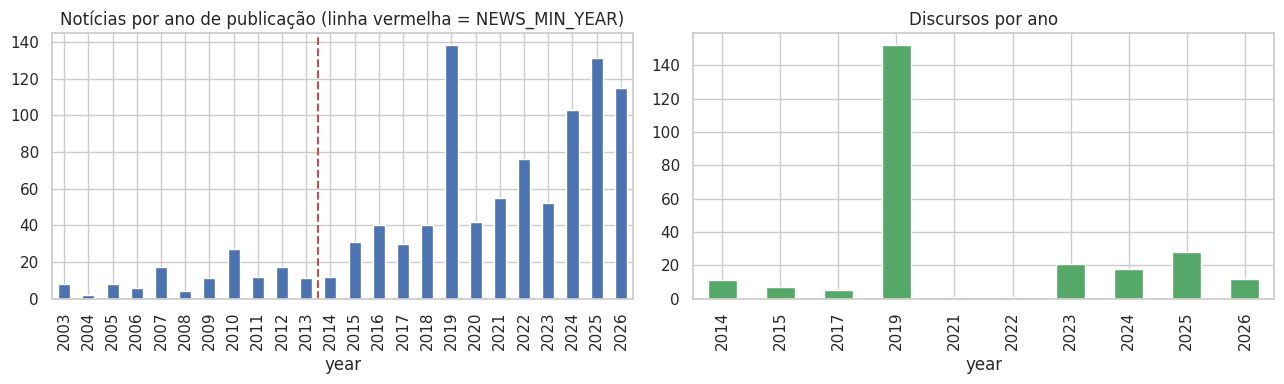

In [6]:
cov = (pd.DataFrame({"n_noticias": news.groupby("party_sigla").size(),
                     "n_discursos": sp.groupby("party_n").size()})
         .fillna(0).astype(int).sort_values("n_discursos", ascending=False))
cov["situacao"] = np.select(
    [(cov.n_noticias > 0) & (cov.n_discursos > 0), (cov.n_noticias > 0), (cov.n_discursos > 0)],
    ["comparável", "só notícias", "só discursos (sem notícias)"], "—")
display(cov)
print(cov.groupby("situacao")[["n_noticias", "n_discursos"]].sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
news.year.dropna().astype(int).value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
yrs = sorted(news.year.dropna().astype(int).unique())
ax[0].set_title("Notícias por ano de publicação (linha vermelha = NEWS_MIN_YEAR)"); ax[0].axvline(np.searchsorted(yrs, NEWS_MIN_YEAR) - .5, color="r", ls="--")
sp.year.value_counts().sort_index().plot.bar(ax=ax[1], color="#55A868"); ax[1].set_title("Discursos por ano")
plt.tight_layout(); plt.show()

## 2. O motor de classificação: Manacá-1B como *scorer* de rótulos

### 2.1 Por que não "pedir a resposta"?

Num modelo base, a pergunta *"esta notícia é sobre armas? responda sim ou não"* não é uma instrução: é só um texto a ser continuado. A forma confiável de usá-lo é **classificação por verossimilhança**: mostramos alguns exemplos já respondidos e pedimos que o modelo continue o padrão; então comparamos a probabilidade da **primeira palavra** de cada rótulo possível.

$$P(\text{rótulo}_k \mid \text{prompt}) \;=\; \operatorname{softmax}_k\big(\log p_\theta(\text{token}_1(\text{rótulo}_k)\mid \text{prompt})\big)$$

Uma única passagem do modelo por texto (não é necessário gerar nada). Verificamos em tempo de execução que a primeira palavra de cada rótulo vira um token **distinto**.

### 2.2 Calibração contextual

Modelos base tendem a preferir certos rótulos independentemente do texto (viés de ordem, de frequência). A **calibração contextual** (Zhao et al., 2021, *Calibrate Before Use*) mede essa preferência com entradas **sem conteúdo** (`"n/d"`, `""`, `"..."`) no *mesmo prompt* e divide a probabilidade observada por ela:

$$\tilde p_k \;\propto\; p_k \,/\, \bar p^{\,\text{sem conteúdo}}_k$$

Guardamos `raw` (sem calibrar) e `cal` (calibrada) para comparar.

### 2.3 Cache

Cada pontuação é guardada em `analysis_outputs_manaca/cache/*.jsonl` com chave = hash do prompt + rótulos. Reexecutar não reprocessa nada, e uma execução interrompida **retoma de onde parou**.

In [7]:
class ManacaScorer:
    """Pontua rótulos candidatos pela probabilidade do 1º token logo após o prompt."""
    def __init__(self, model_id=MODEL_ID, batch_size=BATCH_SIZE):
        import torch
        from transformers import AutoTokenizer, AutoModelForCausalLM
        self.torch = torch
        self.bs = batch_size
        self.tok = AutoTokenizer.from_pretrained(model_id)
        if self.tok.pad_token is None:
            self.tok.pad_token = self.tok.eos_token
        self.tok.padding_side = "left"          # necessário para ler o logit da última posição
        cuda = torch.cuda.is_available()
        dtype = torch.bfloat16 if cuda else torch.float32
        kw = dict(device_map="auto") if cuda else {}
        try:
            self.model = AutoModelForCausalLM.from_pretrained(model_id, dtype=dtype, **kw)
        except TypeError:                        # transformers < 5
            self.model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype, **kw)
        self.model.eval()
        self.device = self.model.device
        print(f"Manacá carregado em {self.device} ({dtype}); {sum(p.numel() for p in self.model.parameters())/1e9:.2f} B de parâmetros")

    def label_token_ids(self, probe_prompt, labels):
        base = self.tok(probe_prompt)["input_ids"]
        ids = []
        for lab in labels:
            full = self.tok(probe_prompt + lab)["input_ids"]
            k = 0
            while k < min(len(base), len(full)) and base[k] == full[k]:
                k += 1
            ids.append(full[k])
        if len(set(ids)) != len(ids):
            raise ValueError(f"Os rótulos {labels} compartilham o 1º token ({ids}). Escolha palavras diferentes.")
        return ids

    def label_logprobs(self, prompts, labels, probe_prompt=None):
        torch = self.torch
        ids = self.label_token_ids(probe_prompt or prompts[0], labels)
        order = np.argsort([len(p) for p in prompts])
        lp = np.zeros((len(prompts), len(labels)), dtype=np.float32)
        mass = np.zeros(len(prompts), dtype=np.float32)
        with torch.no_grad():
            for s in range(0, len(prompts), self.bs):
                idx = order[s:s + self.bs]
                enc = self.tok([prompts[i] for i in idx], return_tensors="pt", padding=True).to(self.device)
                enc.pop("token_type_ids", None)
                pos = (enc["attention_mask"].cumsum(-1) - 1).clamp(min=0)
                try:
                    out = self.model(**enc, position_ids=pos, logits_to_keep=1)
                except TypeError:
                    out = self.model(**enc, position_ids=pos)
                full = torch.log_softmax(out.logits[:, -1, :].float(), dim=-1)[:, ids]   # log-prob no vocabulário todo
                mass[idx] = torch.logsumexp(full, dim=-1).cpu().numpy()                    # massa total nos rótulos
                lp[idx] = torch.log_softmax(full, dim=-1).cpu().numpy()                    # renormaliza entre rótulos
        return lp, mass


class DryRunScorer:
    """SIMULADOR determinístico (palavras-chave + ruído). Só serve para testar o notebook sem GPU."""
    FAV = ["legitima defesa", "direito", "liberdade", "porte", "posse", "cidadao de bem", "flexibiliza", "ampliacao", "ampliar"]
    CON = ["desarmamento", "violencia", "feminicidio", "restric", "armamentismo", "mortes", "controle", "contra o projeto", "criticou"]
    def __init__(self):
        print("⚠️  BACKEND=dryrun: pontuações FICTÍCIAS. Não interprete nenhum resultado.")
    def label_logprobs(self, prompts, labels, probe_prompt=None):
        lp = np.zeros((len(prompts), len(labels)), dtype=np.float32)
        for i, p in enumerate(prompts):
            body = norm_text(p.rsplit("Texto:", 1)[-1])
            rng = np.random.default_rng(int(hashlib.md5(p.encode()).hexdigest()[:8], 16))
            if len(labels) == 2:
                x = math.log1p(len(KW_RX.findall(body))) - 0.8 + rng.normal(0, .4)
                z = np.array([x, -x])
            else:
                fav = sum(body.count(w) for w in self.FAV); con = sum(body.count(w) for w in self.CON)
                z = np.array([fav, con, 0.7]) + rng.normal(0, .5, 3)
            lp[i] = z - logsumexp(z)
        return lp, np.full(len(prompts), -0.5, dtype=np.float32)


scorer = ManacaScorer() if BACKEND == "manaca" else DryRunScorer()


class ScoreCache:
    def __init__(self, path):
        self.path, self.d = Path(path), {}
        if self.path.exists():
            for line in self.path.read_text().splitlines():
                r = json.loads(line); self.d[r["k"]] = (np.array(r["lp"], dtype=np.float32), r["m"])
    def append(self, rows):
        with open(self.path, "a") as f:
            for k, lp, m in rows:
                self.d[k] = (np.array(lp, dtype=np.float32), float(m))
                f.write(json.dumps({"k": k, "lp": [float(x) for x in lp], "m": float(m)}) + "\n")

CACHE = ScoreCache(OUT_DIR / "cache" / f"scores_{BACKEND}_{MODEL_ID.replace('/', '_')}.jsonl")

def score_prompts(prompts, labels, desc="", chunk=64):
    """Pontua com cache. Retorna (log-probs normalizadas [N, L], massa nos rótulos [N])."""
    keys = [hashlib.md5(("|".join(labels) + "\n" + p).encode()).hexdigest() for p in prompts]
    missing = [i for i, k in enumerate(keys) if k not in CACHE.d]
    if missing:
        print(f"[{desc}] pontuando {len(missing)} de {len(prompts)} prompts (restante em cache)")
        t0 = time.time()
        for s in range(0, len(missing), chunk):
            part = missing[s:s + chunk]
            lp, m = scorer.label_logprobs([prompts[i] for i in part], labels, probe_prompt=prompts[0])
            CACHE.append([(keys[i], lp[j], m[j]) for j, i in enumerate(part)])
            print(f"   {min(s + chunk, len(missing))}/{len(missing)}  ({time.time() - t0:.0f}s)", end="\r")
        print()
    return np.stack([CACHE.d[k][0] for k in keys]), np.array([CACHE.d[k][1] for k in keys])

config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.33M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B / 1.44MB            

tokenizer.model: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.45GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Manacá carregado em cuda:0 (torch.bfloat16); 1.72 B de parâmetros


### 2.4 Os prompts

Cada tarefa tem: uma **instrução** que define o conceito, **6 demonstrações sintéticas** (escritas para este trabalho, **sem relação com o corpus**, portanto sem vazamento) e a pergunta final. As demonstrações são intercaladas (Sim/Não e favorável/contrário/neutro alternados) para não induzir viés de posição.

* **Relevância** — rótulos `Sim` / `Não`: o texto trata de **armas de fogo como política pública**? Uso figurado (*"arma contra os pobres"*) ou menção de passagem **não** contam.
* **Postura** — rótulos `favorável` / `contrário` / `neutro`: posição sobre a **flexibilização do acesso a armas** (ampliar porte, posse, comércio, armamento da população).

In [8]:
TASKS = {
 "relevance": dict(
    labels=[" Sim", " Não"],
    instr=("A tarefa é decidir se um texto trata de armas de fogo como tema de política pública: porte, posse, "
           "comércio, registro, Estatuto do Desarmamento, armamento da população, CACs. Textos que usam a palavra "
           "'arma' em sentido figurado, ou que citam armas apenas de passagem em outro assunto, não contam.\n\n"),
    demos=[
     ("O plenário aprovou o projeto que amplia o porte de armas de fogo para colecionadores, atiradores e caçadores (CACs). Parlamentares divergiram sobre o impacto do aumento de armas em circulação.", "Sim"),
     ("A prefeitura inaugurou a nova unidade de saúde do bairro, com atendimento de pediatria e vacinação. Segundo a secretária, a obra custou R$ 3 milhões.", "Não"),
     ("A bancada apresentou requerimento contra o decreto que flexibiliza a compra de munição e de armas por civis, e defendeu a manutenção do Estatuto do Desarmamento.", "Sim"),
     ("O partido critica a nova reforma tributária. Para o líder, a proposta é uma arma contra os mais pobres e precisa ser rediscutida com a sociedade.", "Não"),
     ("Dados do instituto mostram que o número de armas registradas por civis cresceu nos últimos anos, e pesquisadores associam o aumento à flexibilização das regras de posse.", "Sim"),
     ("A comissão debateu o orçamento da educação para o próximo ano e a valorização dos professores. A reunião foi encerrada após a votação do requerimento de informações.", "Não"),
    ],
    question="O texto trata de política de armas de fogo?",
 ),
 "stance": dict(
    labels=[" favorável", " contrário", " neutro"],
    instr=("A tarefa é identificar a posição do texto sobre a flexibilização do acesso a armas de fogo no Brasil "
           "(ampliar porte, posse, comércio ou armamento da população). Favorável: defende ampliar o acesso ou o porte, "
           "ou critica restrições e o desarmamento. Contrário: defende restringir o acesso, manter ou reforçar o "
           "desarmamento, ou critica o armamentismo. Neutro: apenas informa ou descreve, sem tomar posição.\n\n"),
    demos=[
     ("O deputado defendeu a ampliação do porte de armas para o cidadão de bem, argumentando que o Estatuto do Desarmamento retirou o direito à legítima defesa e não reduziu a violência.", "favorável"),
     ("A bancada criticou o decreto que facilita o acesso a armas e munição, alertando que mais armas em circulação aumentam homicídios e feminicídios, e defendeu o fortalecimento do Estatuto do Desarmamento.", "contrário"),
     ("A Câmara realizou audiência pública para discutir o Estatuto do Desarmamento. Participaram representantes do governo, de entidades da sociedade civil e de associações de atiradores.", "neutro"),
     ("O partido votou contra o projeto que amplia o porte de armas, afirmando que o armamento da população não resolve a segurança pública e coloca em risco a vida de mulheres e jovens.", "contrário"),
     ("O partido comemorou a flexibilização das regras para a compra de armas e munição, afirmando que a medida garante liberdade e permite ao cidadão proteger a família.", "favorável"),
     ("O relatório apresentou o número de armas registradas na Polícia Federal em cada estado entre 2018 e 2022, sem recomendações sobre mudanças na legislação.", "neutro"),
    ],
    question="Posição do texto sobre a flexibilização das armas:",
 ),
}

def build_prompt(task: str, text: str, shots: bool = True) -> str:
    c = TASKS[task]
    demos = "".join(f"Texto: {t}\n{c['question']} {l}\n\n" for t, l in c["demos"]) if shots else ""
    return c["instr"] + demos + f"Texto: {text}\n{c['question']}"

print(build_prompt("stance", "<TEXTO A CLASSIFICAR>", shots=True)[-900:])

ntidades da sociedade civil e de associações de atiradores.
Posição do texto sobre a flexibilização das armas: neutro

Texto: O partido votou contra o projeto que amplia o porte de armas, afirmando que o armamento da população não resolve a segurança pública e coloca em risco a vida de mulheres e jovens.
Posição do texto sobre a flexibilização das armas: contrário

Texto: O partido comemorou a flexibilização das regras para a compra de armas e munição, afirmando que a medida garante liberdade e permite ao cidadão proteger a família.
Posição do texto sobre a flexibilização das armas: favorável

Texto: O relatório apresentou o número de armas registradas na Polícia Federal em cada estado entre 2018 e 2022, sem recomendações sobre mudanças na legislação.
Posição do texto sobre a flexibilização das armas: neutro

Texto: <TEXTO A CLASSIFICAR>
Posição do texto sobre a flexibilização das armas:


In [9]:
def calibration_vector(task: str, shots: bool):
    """log p̄ das entradas sem conteúdo, no mesmo prompt (calibração contextual)."""
    cf = ["n/d", "texto", "...", ""]
    lp, _ = score_prompts([build_prompt(task, x, shots) for x in cf], TASKS[task]["labels"], desc=f"calib-{task}-{int(shots)}")
    p_cf = np.exp(lp).mean(0)
    return np.log(p_cf / p_cf.sum())

def calibrate(lp: np.ndarray, calib: np.ndarray) -> np.ndarray:
    """softmax(lp - log p_cf) -> probabilidades calibradas."""
    return softmax(lp - calib, axis=1)

for task in TASKS:
    for shots in (False, True):
        print(f"{task:9s} shots={shots!s:5s}  viés do modelo (p sem conteúdo) =",
              dict(zip([l.strip() for l in TASKS[task]['labels']], np.round(np.exp(calibration_vector(task, shots)), 3))))

[calib-relevance-0] pontuando 4 de 4 prompts (restante em cache)
   4/4  (2s)
relevance shots=False  viés do modelo (p sem conteúdo) = {'Sim': np.float32(0.496), 'Não': np.float32(0.504)}
[calib-relevance-1] pontuando 4 de 4 prompts (restante em cache)
   4/4  (2s)
relevance shots=True   viés do modelo (p sem conteúdo) = {'Sim': np.float32(0.264), 'Não': np.float32(0.736)}
[calib-stance-0] pontuando 4 de 4 prompts (restante em cache)
   4/4  (0s)
stance    shots=False  viés do modelo (p sem conteúdo) = {'favorável': np.float32(0.835), 'contrário': np.float32(0.033), 'neutro': np.float32(0.132)}
[calib-stance-1] pontuando 4 de 4 prompts (restante em cache)
   4/4  (2s)
stance    shots=True   viés do modelo (p sem conteúdo) = {'favorável': np.float32(0.239), 'contrário': np.float32(0.071), 'neutro': np.float32(0.69)}


## 3. Teste de sanidade do Manacá (antes de gastar tempo no corpus)

Dez frases escritas à mão — 5 claramente sobre armas, 5 claramente **não** —, incluindo armadilhas (*"arma" figurada*, *"armazém"*). Se o modelo errar muitas delas, o prompt precisa ser revisto **antes** de processar 1.000+ notícias.

In [10]:
SANITY = [
 ("O governo editou decreto que amplia o número de armas que um cidadão pode comprar e reduz exigências para o registro.", 1),
 ("Projeto no Senado propõe endurecer as regras de porte de armas e proibir a venda de fuzis a civis.", 1),
 ("Pesquisa mostra que estados com mais armas de fogo em circulação registram mais homicídios.", 1),
 ("A bancada defendeu a revogação do Estatuto do Desarmamento em audiência na Câmara.", 1),
 ("Clubes de tiro e CACs pedem a manutenção das regras de acesso a munição e calibres restritos.", 1),
 ("O armazém central da cidade será reformado e ganhará nova área de convivência.", 0),
 ("O candidato disse que vai usar todas as armas políticas disponíveis para vencer a disputa.", 0),
 ("A Câmara aprovou o reajuste do piso dos professores e a ampliação do programa de merenda escolar.", 0),
 ("A seleção estreia no domingo; o técnico confirmou o time titular e a escalação do ataque.", 0),
 ("O partido lançou campanha de vacinação contra a gripe e distribuiu cartilhas nas escolas públicas.", 0),
]
shots_rel = True
lp, _ = score_prompts([build_prompt("relevance", t, shots_rel) for t, _ in SANITY], TASKS["relevance"]["labels"], desc="sanidade")
p_sim = calibrate(lp, calibration_vector("relevance", shots_rel))[:, 0]
san = pd.DataFrame({"texto": [t[:70] + "…" for t, _ in SANITY], "esperado": [y for _, y in SANITY], "P(Sim) calibrada": p_sim.round(3)})
san["acertou"] = (san["P(Sim) calibrada"] >= RELEVANCE_THRESHOLD).astype(int) == san.esperado
display(san)
print(f"acertos: {san.acertou.sum()}/10")

[sanidade] pontuando 10 de 10 prompts (restante em cache)
   10/10  (4s)


,texto,esperado,P(Sim) calibrada,acertou
0,O governo editou decreto que amplia o número de armas que um cidadão p…,1,0.506,True
1,Projeto no Senado propõe endurecer as regras de porte de armas e proib…,1,0.475,True
2,Pesquisa mostra que estados com mais armas de fogo em circulação regis…,1,0.475,True
3,A bancada defendeu a revogação do Estatuto do Desarmamento em audiênci…,1,0.506,True
4,Clubes de tiro e CACs pedem a manutenção das regras de acesso a muniçã…,1,0.506,True
5,O armazém central da cidade será reformado e ganhará nova área de conv…,0,0.413,True
6,O candidato disse que vai usar todas as armas políticas disponíveis pa…,0,0.444,True
7,A Câmara aprovou o reajuste do piso dos professores e a ampliação do p…,0,0.475,False
8,A seleção estreia no domingo; o técnico confirmou o time titular e a e…,0,0.413,True
9,O partido lançou campanha de vacinação contra a gripe e distribuiu car…,0,0.444,True


acertos: 9/10


## 4. Etapa 1 — Pré-tratamento: a notícia **realmente** fala de armas?

As notícias vieram de uma busca por palavras-chave, então muitas são **falsos positivos**: uma matéria sobre feminicídio que cita "arma" uma vez; "arma política"; "armazém". Usamos o Manacá como filtro semântico.

**Entrada do modelo:** título + até 3 janelas de ±350 caracteres em torno das menções a armas (as notícias chegam a 131 mil caracteres, muito além do que importa).

**Decisão:** `relevante = P(Sim) calibrada ≥ RELEVANCE_THRESHOLD`.

### 4.1 Pontuação das notícias

In [11]:
SHOTS_REL = True
labels_rel = TASKS["relevance"]["labels"]
prompts_rel = [build_prompt("relevance", s, SHOTS_REL) for s in news.snippet]
lp_rel, mass_rel = score_prompts(prompts_rel, labels_rel, desc="relevância/notícias")
calib_rel = calibration_vector("relevance", SHOTS_REL)

news["p_sim_raw"] = np.exp(lp_rel[:, 0])
news["p_sim"]     = calibrate(lp_rel, calib_rel)[:, 0]
news["relevant"]  = news.p_sim >= RELEVANCE_THRESHOLD
print(f"massa média nos rótulos Sim/Não (deveria ser alta): {np.exp(mass_rel).mean():.2f}")
print(f"notícias relevantes: {news.relevant.sum()} de {len(news)}  ({news.relevant.mean():.1%})")

[relevância/notícias] pontuando 988 de 988 prompts (restante em cache)
   988/988  (1033s)
massa média nos rótulos Sim/Não (deveria ser alta): 0.93
notícias relevantes: 896 de 988  (90.7%)


### 4.2 Diagnósticos de validade (sem rótulo manual)

Não há gabarito de relevância para as notícias, então triangulamos com três evidências **independentes**:

1. **Distribuição de P(Sim)**: um bom classificador produz distribuição bimodal (poucos casos "em cima do muro").
2. **Controle positivo**: os 256 discursos são, por construção, *sobre* armas; o modelo deve marcar quase todos como relevantes.
3. **Convergência com palavras-chave estritas**: notícias com muitas menções (`kw_hits`) e menções no título devem ter P(Sim) maior; notícias com **zero** menção estrita (casamento por substring) devem ser descartadas.

[relevância/discursos (controle)] pontuando 256 de 256 prompts (restante em cache)
   256/256  (156s)


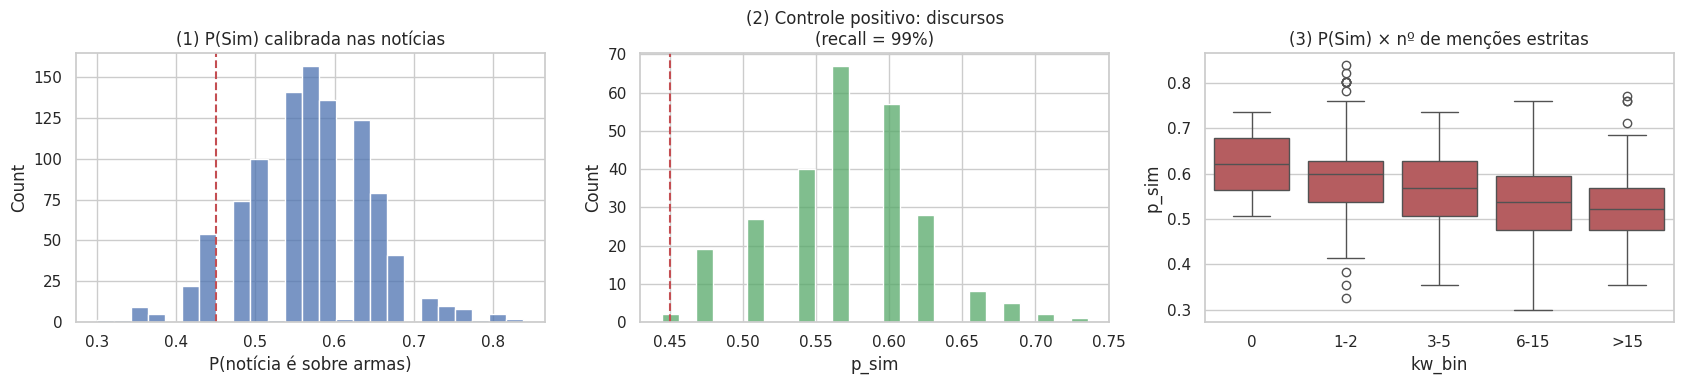

Relevante × título menciona armas:


relevant,False,True,All
title_hit,,,
False,29,613,642
True,63,283,346
All,92,896,988


Relevante × nº de menções estritas:


relevant,False,True,All
kw_bin,,,
0,0,2,2
1-2,23,467,490
3-5,12,178,190
6-15,40,190,230
>15,17,59,76
All,92,896,988


In [12]:
# (2) controle positivo nos discursos
lp_sp_rel, _ = score_prompts([build_prompt("relevance", t, SHOTS_REL) for t in sp["resumo"]], labels_rel, desc="relevância/discursos (controle)")
sp["p_sim"] = calibrate(lp_sp_rel, calib_rel)[:, 0]
recall_pos = (sp.p_sim >= RELEVANCE_THRESHOLD).mean()

# (3) convergência com palavras-chave
news["kw_bin"] = pd.cut(news.kw_hits, [-1, 0, 2, 5, 15, 10**6], labels=["0", "1-2", "3-5", "6-15", ">15"])
news["title_hit"] = news.titulo.map(lambda s: bool(KW_RX.search(norm_text(s))))

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(news.p_sim, bins=25, ax=ax[0], color="#4C72B0"); ax[0].axvline(RELEVANCE_THRESHOLD, color="r", ls="--")
ax[0].set_title("(1) P(Sim) calibrada nas notícias"); ax[0].set_xlabel("P(notícia é sobre armas)")
sns.histplot(sp.p_sim, bins=25, ax=ax[1], color="#55A868"); ax[1].axvline(RELEVANCE_THRESHOLD, color="r", ls="--")
ax[1].set_title(f"(2) Controle positivo: discursos\n(recall = {recall_pos:.0%})")
sns.boxplot(data=news, x="kw_bin", y="p_sim", ax=ax[2], color="#C44E52"); ax[2].set_title("(3) P(Sim) × nº de menções estritas")
plt.tight_layout(); plt.show()

print("Relevante × título menciona armas:"); display(pd.crosstab(news.title_hit, news.relevant, margins=True))
print("Relevante × nº de menções estritas:"); display(pd.crosstab(news.kw_bin, news.relevant, margins=True))

### 4.3 O que o filtro removeu? (inspeção qualitativa)

Sempre olhe os dois lados da fronteira: notícias **descartadas com muitas menções** (possível erro do filtro) e notícias **mantidas com poucas menções** (possível erro do filtro, na outra direção).

In [13]:
def show(df, n=4, title=""):
    print("\n" + "=" * 100 + f"\n{title}\n" + "=" * 100)
    for _, r in df.head(n).iterrows():
        print(f"[{r.party_sigla} | {r.year} | P(Sim)={r.p_sim:.2f} | menções={r.kw_hits}] {r.titulo[:110]}\n    {r.snippet[len(r.titulo):len(r.titulo)+260]}…\n")

show(news[~news.relevant].sort_values("kw_hits", ascending=False), title="DESCARTADAS com mais menções a armas (erro do filtro?)")
show(news[news.relevant].sort_values("kw_hits"), title="MANTIDAS com menos menções a armas (erro do filtro?)")
show(news[(news.p_sim - RELEVANCE_THRESHOLD).abs() < .08], title="CASOS DE FRONTEIRA")


DESCARTADAS com mais menções a armas (erro do filtro?)
[PV | 2019 | P(Sim)=0.41 | menções=46] Decreto das armas de Bolsonaro tem ilegalidades, aponta análise técnica da Câmara
    . Outra análise, feita por técnicos do Senado, diz que a norma assinada pelo presidente da República para facilitar porte de armas ‘extrapolou o poder regulamentar’. A área técnica da Câmara dos Deputados elaborou um parecer para enviar ao presidente da Casa, …

[PCdoB | 2023 | P(Sim)=0.41 | menções=27] Número de armas pessoais dispara e chega a quase 3 milhões
    . Número de armas pessoais dispara e chega a quase 3 milhões Dentre os muitos legados negativos deixados por Bolsonaro, um dos que mais têm poder de impactar a vida de toda a população é o salto no aumento do número de armas de fogo em circulação no país. Segu…

[PSD | 2024 | P(Sim)=0.44 | menções=27] Em debate, as mudanças no Estatuto do Desarmamento - PSD - Partido Social Democrático
    . Da esquerda para a direita: Coronel Álvaro Camilo, Bené 

### 4.4 Validação manual opcional (recomendada)

O jeito mais forte de validar é rotular uma amostra à mão. A célula exporta **80 notícias** (amostragem estratificada por faixa de P(Sim), para incluir casos difíceis). Preencha a coluna `rotulo_manual` com `1` (sobre armas) ou `0` e **reexecute**: o notebook calcula precisão/revocação e sugere um limiar.

In [14]:
import csv

def export_annotation_sheet(df, path, n, prob_col, cols, seed=SEED):
    if Path(path).exists():
        print(f"já existe: {path}"); return
    d = df.copy(); d["faixa"] = pd.qcut(d[prob_col].rank(method="first"), 5, labels=False)
    out = d.groupby("faixa", group_keys=False).apply(lambda g: g.sample(min(len(g), n // 5), random_state=seed))
    out = out[cols].assign(rotulo_manual="")
    out.to_csv(path, index=False, quoting=csv.QUOTE_NONNUMERIC); print(f"planilha gerada: {path}  ({len(out)} linhas)")

ANN_REL = OUT_DIR / "anotacao_relevancia.csv"
export_annotation_sheet(news.assign(trecho=news.snippet.str[:500]), ANN_REL, 80, "p_sim",
                        ["news_id", "party_sigla", "titulo", "trecho", "p_sim"])

if ANN_REL.exists():
    ann = pd.read_csv(ANN_REL, dtype={"rotulo_manual": "string"})
    ann = ann[ann.rotulo_manual.isin(["0", "1"])].assign(y=lambda d: d.rotulo_manual.astype(int))
    if len(ann) >= 20:
        from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
        pr = precision_recall_fscore_support(ann.y, ann.p_sim >= RELEVANCE_THRESHOLD, average="binary")
        print(f"n rotulado={len(ann)} | precisão={pr[0]:.2f} revocação={pr[1]:.2f} F1={pr[2]:.2f} | AUC={roc_auc_score(ann.y, ann.p_sim):.2f}")
        ths = np.linspace(.05, .95, 19)
        f1s = [precision_recall_fscore_support(ann.y, ann.p_sim >= t, average="binary")[2] for t in ths]
        print(f"limiar que maximiza F1 na amostra: {ths[int(np.argmax(f1s))]:.2f} (considere ajustar RELEVANCE_THRESHOLD)")
    else:
        print("Preencha a coluna rotulo_manual (≥ 20 linhas) e reexecute para ver as métricas.")

planilha gerada: /analysis_outputs_manaca/anotacao_relevancia.csv  (80 linhas)
Preencha a coluna rotulo_manual (≥ 20 linhas) e reexecute para ver as métricas.


### 4.5 Resultado da etapa 1: quanto de cada partido sobrevive?

Esta tabela é um **achado** em si: partidos cujas notícias "sobre armas" são majoritariamente falsos positivos quase não têm posição própria sobre o tema.

In [15]:
rel_tab = (news[news.year >= NEWS_MIN_YEAR].groupby("party_sigla")
           .agg(n_total=("news_id", "size"), n_relevantes=("relevant", "sum"), p_sim_medio=("p_sim", "mean"))
           .assign(taxa_relevante=lambda d: d.n_relevantes / d.n_total).sort_values("n_relevantes", ascending=False))
display(rel_tab.round(3))
news.drop(columns=["texto_cru"]).to_csv(OUT_DIR / "news_relevance.csv", index=False)

,n_total,n_relevantes,p_sim_medio,taxa_relevante
party_sigla,,,,
PCdoB,118,110,0.576,0.932
PCB,109,107,0.601,0.982
PV,75,68,0.577,0.907
REPUBLICANOS,74,68,0.559,0.919
PSOL,71,65,0.547,0.915
PT,71,64,0.552,0.901
PSB,74,59,0.531,0.797
PSD,58,51,0.541,0.879
PSDB,54,48,0.558,0.889


## 5. Etapa 2 — Postura: favorável, contrária ou neutra?

Agora o mesmo mecanismo responde a segunda pergunta: **qual a posição do texto sobre flexibilizar o acesso a armas?** Para cada texto obtemos três probabilidades calibradas $(p_{fav}, p_{con}, p_{neu})$ e dois derivados:

$$s_i \;=\; p_{fav,i} - p_{con,i} \;\in[-1,+1] \qquad \text{(índice de postura suave)}$$

$$\text{classe}_i = \arg\max(p_{fav},p_{con},p_{neu}) \qquad \text{(rótulo duro)}$$

O índice suave $s_i$ preserva a incerteza (um texto 40/35/25 vale quase 0, não "favorável") e é a base das métricas.

### 5.1 Validação nos discursos — temos gabarito!

Os discursos trazem o campo `stance` (PRO/CON/NEUTRAL), anotado de forma independente do Manacá. Usamos esse campo como **referência** (não como verdade absoluta: pode conter erros) para responder, **antes** de tocar nas notícias:

* o Manacá recupera a posição dos discursos? (macro-F1, matriz de confusão);
* a calibração ajuda?
* o *few-shot* ajuda em relação ao *zero-shot*?
* qual texto de entrada funciona melhor: `resumo` (resumo + tese central), `fala` (transcrição do orador) ou `ambos`?

A melhor configuração (maior macro-F1 calibrado) é adotada na análise — **o que introduz um otimismo leve** (escolhemos a configuração nos mesmos 256 discursos em que a medimos); por isso o número reportado deve ser lido como um *teto*, e a validação manual das notícias (4.4 e 5.3) é o teste honesto.

In [16]:
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix, classification_report

LAB3 = ["favorável", "contrário", "neutro"]
labels_st = TASKS["stance"]["labels"]
SPEECH_MODES = ["resumo", "fala", "ambos"]

def stance_probs(texts, shots, desc):
    lp, _ = score_prompts([build_prompt("stance", t, shots) for t in texts], labels_st, desc=desc)
    return np.exp(lp), calibrate(lp, calibration_vector("stance", shots))

rows, store = [], {}
for shots in (False, True):
    for mode in SPEECH_MODES:
        raw, cal = stance_probs(sp[mode], shots, f"postura/discursos shots={shots} modo={mode}")
        y_true = sp.ref_stance.values
        pr_raw = np.array(LAB3)[raw.argmax(1)]; pr_cal = np.array(LAB3)[cal.argmax(1)]
        rows.append(dict(few_shot=shots, entrada=mode,
                         macroF1_raw=f1_score(y_true, pr_raw, average="macro", labels=LAB3),
                         macroF1_cal=f1_score(y_true, pr_cal, average="macro", labels=LAB3),
                         bal_acc_cal=balanced_accuracy_score(y_true, pr_cal),
                         acc_cal=(pr_cal == y_true).mean()))
        store[(shots, mode)] = (raw, cal)

abl = pd.DataFrame(rows).sort_values("macroF1_cal", ascending=False).reset_index(drop=True)
display(abl.round(3))

best = abl.iloc[0]
BEST_SHOTS = bool(best.few_shot) if USE_FEW_SHOT is None else USE_FEW_SHOT
BEST_MODE  = best.entrada if SPEECH_TEXT_MODE is None else SPEECH_TEXT_MODE
print(f"\n→ configuração adotada: few_shot={BEST_SHOTS}, entrada='{BEST_MODE}'")

[postura/discursos shots=False modo=resumo] pontuando 256 de 256 prompts (restante em cache)
   256/256  (66s)
[postura/discursos shots=False modo=fala] pontuando 256 de 256 prompts (restante em cache)
   256/256  (151s)
[postura/discursos shots=False modo=ambos] pontuando 256 de 256 prompts (restante em cache)
   256/256  (186s)
[postura/discursos shots=True modo=resumo] pontuando 256 de 256 prompts (restante em cache)
   256/256  (162s)
[postura/discursos shots=True modo=fala] pontuando 256 de 256 prompts (restante em cache)
   256/256  (254s)
[postura/discursos shots=True modo=ambos] pontuando 256 de 256 prompts (restante em cache)
   256/256  (292s)


,few_shot,entrada,macroF1_raw,macroF1_cal,bal_acc_cal,acc_cal
0,True,resumo,0.054,0.306,0.346,0.492
1,False,resumo,0.241,0.280,0.359,0.441
2,True,ambos,0.042,0.227,0.320,0.250
3,False,fala,0.248,0.180,0.316,0.359
4,False,ambos,0.248,0.179,0.323,0.367
5,True,fala,0.027,0.142,0.250,0.121



→ configuração adotada: few_shot=True, entrada='resumo'


              precision    recall  f1-score   support

   favorável      0.588     0.781     0.671       146
   contrário      0.833     0.103     0.183        97
      neutro      0.040     0.154     0.063        13

    accuracy                          0.492       256
   macro avg      0.487     0.346     0.306       256
weighted avg      0.653     0.492     0.455       256



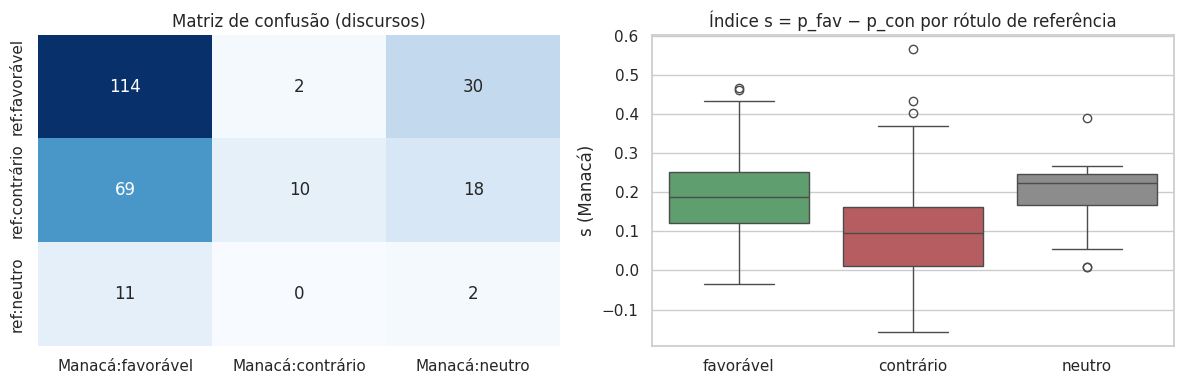

AUC do índice s para separar favorável × contrário (sem neutros): 0.728


In [17]:
raw, cal = store[(BEST_SHOTS, BEST_MODE)]
pred = np.array(LAB3)[cal.argmax(1)]
print(classification_report(sp.ref_stance, pred, labels=LAB3, digits=3, zero_division=0))

cm = pd.DataFrame(confusion_matrix(sp.ref_stance, pred, labels=LAB3), index=[f"ref:{l}" for l in LAB3], columns=[f"Manacá:{l}" for l in LAB3])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False); ax[0].set_title("Matriz de confusão (discursos)")
s_speech = cal[:, 0] - cal[:, 1]
sns.boxplot(x=sp.ref_stance, y=s_speech, order=LAB3, ax=ax[1], palette=["#55A868", "#C44E52", "#8C8C8C"])
ax[1].set_title("Índice s = p_fav − p_con por rótulo de referência"); ax[1].set_ylabel("s (Manacá)"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

from sklearn.metrics import roc_auc_score
ysub = sp.ref_stance[sp.ref_stance != "neutro"]
print(f"AUC do índice s para separar favorável × contrário (sem neutros): {roc_auc_score((ysub=='favorável').astype(int), s_speech[ysub.index]):.3f}")

### 5.2 Postura de cada discurso (insumo da etapa dos deputados)

Guardamos as probabilidades da configuração escolhida. A comparação com `ref_stance` permanece nas tabelas como **diagnóstico**, mas as métricas dos deputados (seção 7) usam **apenas** as saídas do Manacá.

In [18]:
sp["p_fav"], sp["p_con"], sp["p_neu"] = cal[:, 0], cal[:, 1], cal[:, 2]
sp["s"] = sp.p_fav - sp.p_con
sp["manaca_stance"] = pred
sp["manaca_conf"] = cal.max(1)
sp[["id","deputy_id","deputy_name","party","party_n","event_id","speech_type","year","ref_stance","manaca_stance","p_fav","p_con","p_neu","s","manaca_conf"]] \
  .to_csv(OUT_DIR / "speech_stance.csv", index=False)
display(sp[["deputy_name","party_n","ref_stance","manaca_stance","p_fav","p_con","p_neu","s"]].head(8).round(3))

,deputy_name,party_n,ref_stance,manaca_stance,p_fav,p_con,p_neu,s
0,Severino Ninho,PSB,favorável,favorável,0.478,0.281,0.241,0.197
1,Izalci,PSDB,favorável,favorável,0.492,0.289,0.219,0.203
2,Rubens Bueno,CIDADANIA,favorável,favorável,0.384,0.255,0.361,0.128
3,Arlindo Chinaglia,PT,neutro,favorável,0.568,0.179,0.253,0.390
4,Jandira Feghali,PCdoB,favorável,favorável,0.517,0.304,0.179,0.214
5,Dr. Carlos Alberto,PMN,favorável,favorável,0.448,0.263,0.290,0.185
6,Afonso Hamm,PP,favorável,favorável,0.448,0.263,0.290,0.185
7,Vieira da Cunha,PDT,favorável,favorável,0.461,0.307,0.232,0.154


### 5.3 Postura das notícias **relevantes**

Mesma configuração (`BEST_SHOTS`), aplicada ao trecho de contexto de cada notícia que passou no filtro da etapa 1. Notícias descartadas **não** entram.

> **Diferença de domínio:** validamos nos discursos (fala parlamentar) e aplicamos em notícias de sites partidários (texto jornalístico/institucional). O desempenho nas notícias pode ser diferente — daí a planilha de validação manual abaixo.

[postura/notícias relevantes] pontuando 896 de 896 prompts (restante em cache)
   896/896  (946s)
                 n    pct
manaca_stance            
neutro         773  0.863
favorável      110  0.123
contrário       13  0.015


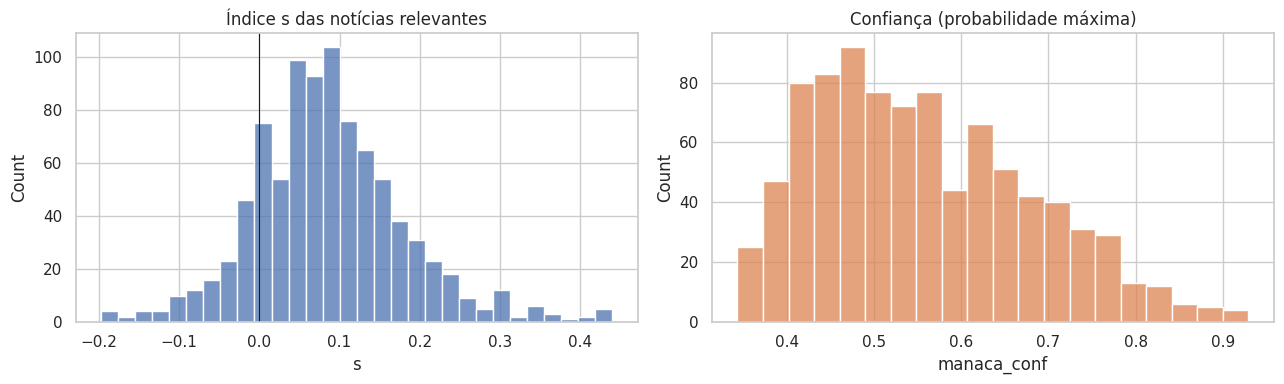

planilha gerada: /analysis_outputs_manaca/anotacao_postura.csv  (60 linhas)

Preencha rotulo_manual com: favorável / contrário / neutro (≥ 20 linhas) e reexecute para validar.


In [19]:
nrel = news[news.relevant].copy()
raw_n, cal_n = stance_probs(nrel.snippet, BEST_SHOTS, "postura/notícias relevantes")
nrel["p_fav"], nrel["p_con"], nrel["p_neu"] = cal_n[:, 0], cal_n[:, 1], cal_n[:, 2]
nrel["s"] = nrel.p_fav - nrel.p_con
nrel["manaca_stance"] = np.array(LAB3)[cal_n.argmax(1)]
nrel["manaca_conf"] = cal_n.max(1)

news = news.merge(nrel[["news_id", "p_fav", "p_con", "p_neu", "s", "manaca_stance", "manaca_conf"]], on="news_id", how="left")
print(nrel.manaca_stance.value_counts().rename("n").to_frame().assign(pct=lambda d: (d.n / d.n.sum()).round(3)))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(nrel.s, bins=30, ax=ax[0], color="#4C72B0"); ax[0].set_title("Índice s das notícias relevantes"); ax[0].axvline(0, color="k", lw=.8)
sns.histplot(nrel.manaca_conf, bins=20, ax=ax[1], color="#DD8452"); ax[1].set_title("Confiança (probabilidade máxima)")
plt.tight_layout(); plt.show()

ANN_ST = OUT_DIR / "anotacao_postura.csv"
export_annotation_sheet(nrel.assign(trecho=nrel.snippet.str[:600], manaca=nrel.manaca_stance), ANN_ST, 60, "s",
                        ["news_id", "party_sigla", "titulo", "trecho", "manaca", "s"])
if ANN_ST.exists():
    a = pd.read_csv(ANN_ST, dtype={"rotulo_manual": "string"})
    a = a[a.rotulo_manual.isin(LAB3)]
    if len(a) >= 20:
        print(f"\nValidação manual da postura (n={len(a)}): macro-F1={f1_score(a.rotulo_manual, a.manaca, average='macro'):.3f}  acurácia={(a.rotulo_manual == a.manaca).mean():.3f}")
        print(classification_report(a.rotulo_manual, a.manaca, labels=LAB3, zero_division=0))
    else:
        print("\nPreencha rotulo_manual com: favorável / contrário / neutro (≥ 20 linhas) e reexecute para validar.")

### 5.4 Inspeção qualitativa por partido

Para cada partido, a notícia mais favorável e a mais contrária segundo o Manacá. Se os exemplos não fizerem sentido, **pare aqui** e revise os prompts.

In [20]:
for p in ["PT", "PL", "PSOL", "NOVO"]:
    g = nrel[(nrel.party_sigla == p) & (nrel.year >= NEWS_MIN_YEAR)].sort_values("s")
    if g.empty: print(f"\n[{p}] sem notícias relevantes"); continue
    for tag, r in [("MAIS CONTRÁRIA", g.iloc[0]), ("MAIS FAVORÁVEL", g.iloc[-1])]:
        print(f"\n[{p}] {tag}  s={r.s:+.2f}  ({r.year})  {r.titulo[:100]}\n   …{r.snippet[len(r.titulo)+2:len(r.titulo)+300]}…")


[PT] MAIS CONTRÁRIA  s=-0.18  (2021)  PT vai ao Supremo contra novos decretos de armas de Bolsonaro – Partido dos Trabalhadores
   …O Partido dos Trabalhadores protocolou nessa quarta (17) Ação Direta de Inconstitucionalidade no Supremo Tribunal Federal (STF) contra os decretos publicados pelo presidente Jair Bolsonaro na véspera do feriado de Carnaval que facilitam e ampliam o acesso às armas de fogo e munições. O partido ped…

[PT] MAIS FAVORÁVEL  s=+0.30  (2022)  Após eleição de Lula, investimentos da Bolsa sobem em educação e caem em armas – Partido dos Trabalh
   …A prosperidade econômica com Lula na presidência do Brasil começa a dar o ar de sua graça. Investidores da Bolsa de Valores brasileira favorecem a educação e desprestigiam a fabricação de armas. Na últiima segunda-feira, 31, um movimento de rotação de ações deu preferência aos ativos que podem ser…

[PL] MAIS CONTRÁRIA  s=+0.01  (2025)  Senador Magno Malta é relator de projeto que autoriza porte de armas para mulheres s

## 6. Etapa 3 — Métricas empíricas do **partido**

Para o partido $p$ com $N_p$ notícias no período, das quais $R_p$ foram julgadas relevantes (etapa 1) e, entre elas, $F_p$ favoráveis, $C_p$ contrárias e $U_p$ neutras (rótulo duro):

| Métrica | Fórmula | Leitura |
|---|---|---|
| **Taxa de relevância** | $R_p / N_p$ | saliência: quanto do que o partido publica "sobre armas" realmente é sobre armas |
| **Favorabilidade sobre o total** | $F_p / N_p$ | a métrica sugerida no enunciado: favoráveis **em relação ao total de notícias do partido** |
| **Favorabilidade sobre as relevantes** | $F_p / R_p$ | posição entre quem de fato fala do tema |
| **Contrariedade** (idem) | $C_p / N_p$ e $C_p / R_p$ | |
| **Índice líquido (duro)** | $(F_p - C_p)/R_p$ | de −1 (tudo contra) a +1 (tudo a favor) |
| **Índice suave** $\bar s_p$ | $\frac1{R_p}\sum_i (p_{fav,i}-p_{con,i})$ | usa as probabilidades, não só o rótulo |
| **Índice com encolhimento** | $\tilde s_p = \dfrac{R_p\,\bar s_p}{R_p + k}$ | puxa partidos com **poucas** notícias para 0 ($k$=`PARTY_PRIOR_K`) |
| **IC 95 %** | bootstrap percentil de $\bar s_p$ (2.000 reamostragens) | incerteza |

**Por que encolhimento?** Com 1 notícia (REDE, DC) o índice seria ±1 — evidência fraca vestida de certeza. A fórmula é a média de uma "pseudo-amostra" que inclui $k$ notícias neutras imaginárias (prior de que, sem evidência, o partido é neutro). Partidos com $R_p$ grande praticamente não são afetados.

**Posição do partido:** `Favorável` se $\tilde s_p \ge \tau$, `Contrária` se $\tilde s_p \le -\tau$, senão `Neutra/Mista`; `Dados insuficientes` se $R_p <$ `MIN_REL_NEWS`. Marcamos `ic_exclui_zero` quando o IC bootstrap não cruza 0.

In [21]:
def boot_ci(x, n_boot=N_BOOT, seed=SEED, alpha=.05):
    x = np.asarray(x, float)
    if len(x) < 2: return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, (n_boot, len(x)), replace=True).mean(1)
    return tuple(np.quantile(means, [alpha / 2, 1 - alpha / 2]))

def position_label(idx, n_rel):
    if n_rel < MIN_REL_NEWS or np.isnan(idx): return "Dados insuficientes"
    return "Favorável" if idx >= POSITION_TAU else ("Contrária" if idx <= -POSITION_TAU else "Neutra/Mista")

def party_metrics(news_df, min_year=NEWS_MIN_YEAR, prior_k=PARTY_PRIOR_K):
    d = news_df[news_df.year >= min_year]
    rows = []
    for party, g in d.groupby("party_sigla"):
        rel = g[g.relevant]
        N, R = len(g), len(rel)
        F = (rel.manaca_stance == "favorável").sum(); C = (rel.manaca_stance == "contrário").sum(); U = (rel.manaca_stance == "neutro").sum()
        soft = rel.s.mean() if R else np.nan
        lo, hi = boot_ci(rel.s.values) if R else (np.nan, np.nan)
        shrunk = (R * soft / (R + prior_k)) if R else np.nan
        rows.append(dict(
            party=party, n_total=N, n_rel=R, n_fav=F, n_con=C, n_neu=U,
            rel_rate=R / N if N else np.nan,
            fav_rate_total=F / N if N else np.nan, con_rate_total=C / N if N else np.nan,
            fav_rate_rel=F / R if R else np.nan, con_rate_rel=C / R if R else np.nan, neu_rate_rel=U / R if R else np.nan,
            net_hard=(F - C) / R if R else np.nan,
            soft_index=soft, shrunk_index=shrunk, ci_lo=lo, ci_hi=hi,
            ic_exclui_zero=bool(R >= 2 and (lo > 0 or hi < 0)),
            s_sd=rel.s.std(ddof=1) if R > 1 else np.nan,
            pfav_mean=rel.p_fav.mean() if R else np.nan, pcon_mean=rel.p_con.mean() if R else np.nan, pneu_mean=rel.p_neu.mean() if R else np.nan,
            posicao=position_label(shrunk, R),
        ))
    return pd.DataFrame(rows).sort_values("shrunk_index", ascending=False).reset_index(drop=True)

party_tab = party_metrics(news)
cols = ["party","n_total","n_rel","rel_rate","fav_rate_total","fav_rate_rel","con_rate_rel","net_hard","soft_index","shrunk_index","ci_lo","ci_hi","ic_exclui_zero","posicao"]
display(party_tab[cols].round(3))
party_tab.to_csv(OUT_DIR / "party_metrics.csv", index=False)

,party,n_total,n_rel,rel_rate,fav_rate_total,fav_rate_rel,con_rate_rel,net_hard,soft_index,shrunk_index,ci_lo,ci_hi,ic_exclui_zero,posicao
0,REPUBLICANOS,74,68,0.919,0.257,0.279,0.000,0.279,0.145,0.135,0.119,0.171,True,Neutra/Mista
1,NOVO,30,29,0.967,0.233,0.241,0.034,0.207,0.151,0.129,0.109,0.196,True,Neutra/Mista
2,MDB,16,15,0.938,0.312,0.333,0.000,0.333,0.152,0.114,0.118,0.196,True,Neutra/Mista
3,PSD,58,51,0.879,0.121,0.137,0.000,0.137,0.114,0.104,0.087,0.142,True,Neutra/Mista
4,PV,75,68,0.907,0.120,0.132,0.000,0.132,0.104,0.097,0.080,0.130,True,Neutra/Mista
5,CIDADANIA,22,22,1.000,0.136,0.136,0.000,0.136,0.101,0.082,0.067,0.135,True,Neutra/Mista
6,PT,71,64,0.901,0.056,0.062,0.031,0.031,0.086,0.080,0.063,0.111,True,Neutra/Mista
7,PCdoB,118,110,0.932,0.042,0.045,0.000,0.045,0.082,0.079,0.069,0.096,True,Neutra/Mista
8,PDT,44,40,0.909,0.136,0.150,0.025,0.125,0.085,0.076,0.056,0.113,True,Neutra/Mista
9,PSB,74,59,0.797,0.054,0.068,0.017,0.051,0.069,0.064,0.046,0.093,True,Neutra/Mista


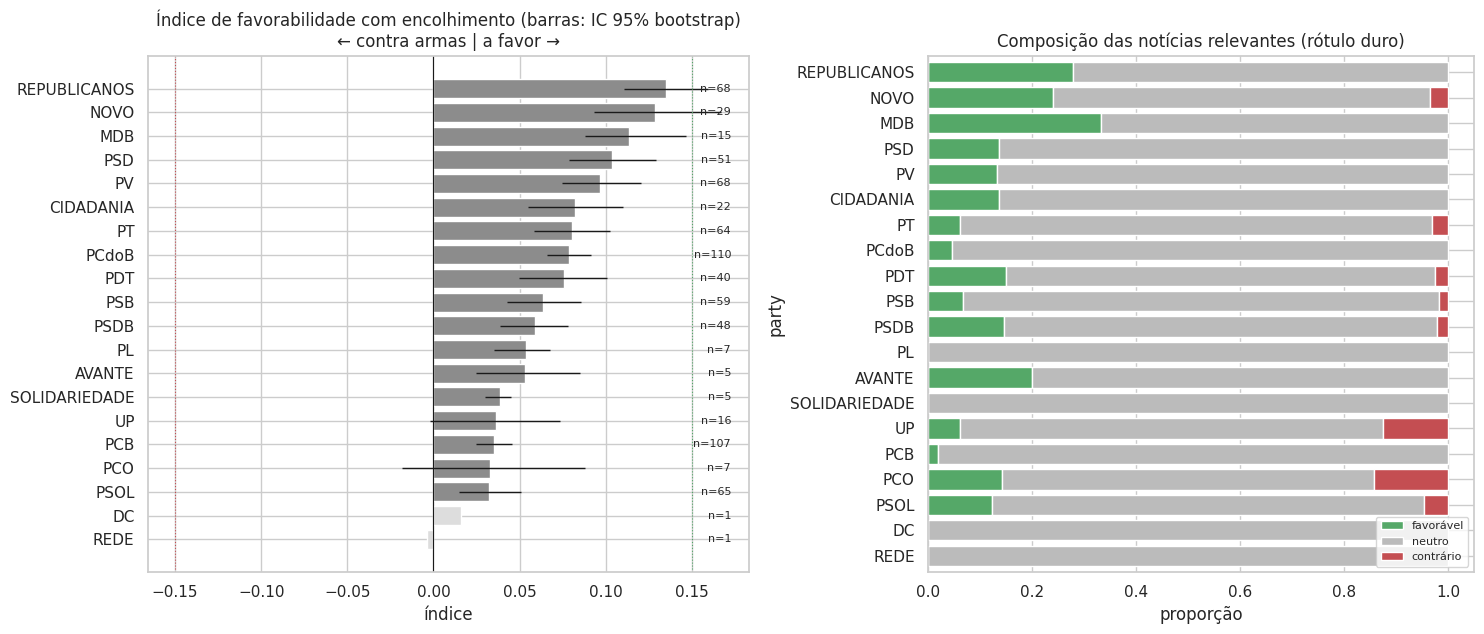

In [22]:
pt = party_tab[party_tab.n_rel > 0].sort_values("shrunk_index")
colors = pt.posicao.map({"Favorável": "#55A868", "Contrária": "#C44E52", "Neutra/Mista": "#8C8C8C", "Dados insuficientes": "#DDDDDD"})
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.1, 1]})
ax[0].barh(pt.party, pt.shrunk_index, color=colors)
ax[0].errorbar(pt.soft_index * pt.n_rel / (pt.n_rel + PARTY_PRIOR_K), pt.party,
               xerr=[(pt.soft_index - pt.ci_lo).clip(lower=0) * pt.n_rel / (pt.n_rel + PARTY_PRIOR_K),
                     (pt.ci_hi - pt.soft_index).clip(lower=0) * pt.n_rel / (pt.n_rel + PARTY_PRIOR_K)],
               fmt="none", ecolor="k", lw=1)
for i, (n, p) in enumerate(zip(pt.n_rel, pt.party)): ax[0].text(ax[0].get_xlim()[1] * .98, i, f"n={n}", va="center", ha="right", fontsize=8)
ax[0].axvline(0, color="k", lw=.8); ax[0].axvline(POSITION_TAU, color="g", ls=":", lw=.8); ax[0].axvline(-POSITION_TAU, color="r", ls=":", lw=.8)
ax[0].set_title("Índice de favorabilidade com encolhimento (barras: IC 95% bootstrap)\n← contra armas | a favor →"); ax[0].set_xlabel("índice")

comp = pt.set_index("party")[["fav_rate_rel", "neu_rate_rel", "con_rate_rel"]]
comp.plot.barh(stacked=True, ax=ax[1], color=["#55A868", "#BBBBBB", "#C44E52"], width=.8)
ax[1].set_title("Composição das notícias relevantes (rótulo duro)"); ax[1].set_xlabel("proporção"); ax[1].legend(["favorável", "neutro", "contrário"], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### 6.1 Sensibilidade: o resultado depende da janela temporal e do limiar de relevância?

Se a posição de um partido muda de sinal ao trocar um parâmetro razoável, ela **não é robusta** e não deve sustentar conclusões. Comparamos o índice com encolhimento para: (a) todas as datas, (b) a janela padrão (≥ `NEWS_MIN_YEAR`) e (c) limiar de relevância mais rígido (0,7).

In [23]:
news_strict = news.copy(); news_strict["relevant"] = news_strict.p_sim >= 0.70
sens = pd.DataFrame({
    "todas_as_datas":   party_metrics(news, min_year=0).set_index("party").shrunk_index,
    f"≥{NEWS_MIN_YEAR} (padrão)": party_metrics(news).set_index("party").shrunk_index,
    "limiar_relev_0.7": party_metrics(news_strict).set_index("party").shrunk_index,
    "n_rel (padrão)":   party_metrics(news).set_index("party").n_rel,
}).dropna(how="all")
sens["muda_de_sinal"] = np.sign(sens.iloc[:, :3]).nunique(axis=1, dropna=True) > 1
display(sens.round(3).sort_values(f"≥{NEWS_MIN_YEAR} (padrão)", ascending=False))

,todas_as_datas,≥2014 (padrão),limiar_relev_0.7,n_rel (padrão),muda_de_sinal
party,,,,,
REPUBLICANOS,0.137,0.135,NaN,68,False
NOVO,0.129,0.129,NaN,29,False
MDB,0.114,0.114,0.013,15,False
PSD,0.104,0.104,0.037,51,False
PV,0.097,0.097,0.087,68,False
CIDADANIA,0.082,0.082,0.017,22,False
PT,0.080,0.080,NaN,64,False
PCdoB,0.078,0.079,0.029,110,False
PDT,0.086,0.076,0.022,40,False


## 7. Etapa 4 — Métricas empíricas do **deputado** e o gap em relação ao partido

**Unidade de análise: parlamentar × partido.** Dez deputados trocaram de partido no período (p. ex. `PSL→PL`, `DEM→PL`); cada discurso é comparado com o partido **vigente na data**, então a unidade é o par `(deputy_id, partido)`.

Para o par $(d,p)$ com $n_d$ discursos, análogos às métricas do partido:

* **favorabilidade sobre o total de discursos** $F_d/n_d$ e contrariedade $C_d/n_d$ (rótulo duro);
* **índice suave** $\bar s_d$ e **com encolhimento** $\tilde s_d = n_d\bar s_d/(n_d + k_d)$, $k_d$ = `DEP_PRIOR_K` (deputados têm 1–6 discursos);

**Medidas de alinhamento com o partido** (usam o índice do partido da seção 6):

| Medida | Definição |
|---|---|
| `gap` | $\tilde s_d - \tilde s_p$ (positivo: deputado mais pró-armas que o partido) |
| `abs_gap` | $\lvert \text{gap}\rvert$ |
| `z` | $(\bar s_d - \bar s_p)/\sigma_p$, com $\sigma_p$ o desvio das notícias do partido (piso 0,10): quão atípico é o deputado *dentro da variação interna do partido* |
| `js` | distância de Jensen–Shannon entre as distribuições $(p_{fav},p_{con},p_{neu})$ médias do deputado e do partido (0 = idênticas, 1 = máx.) |
| `align_code` | 0 = mesma posição; 0,25 = um lado neutro; 1 = posições opostas (usando `POSITION_TAU` nos dois lados) |

In [24]:
PARTY_VOICE = {"ORIENTAÇÃO DE BANCADA", "ENCAMINHAMENTO DE VOTAÇÃO", "COMO LÍDER", "DISCURSO ENCAMINHADO"}

def dep_position(idx):
    return np.where(idx >= POSITION_TAU, 1, np.where(idx <= -POSITION_TAU, -1, 0))

def build_units(sp_df, party_df):
    g = sp_df.assign(voice=sp_df.speech_type.isin(PARTY_VOICE).astype(int),
                     hard_fav=(sp_df.manaca_stance == "favorável").astype(int),
                     hard_con=(sp_df.manaca_stance == "contrário").astype(int),
                     hard_neu=(sp_df.manaca_stance == "neutro").astype(int),
                     ref_s=sp_df.ref_stance.map({"favorável": 1, "contrário": -1, "neutro": 0})
                    ).groupby(["deputy_id", "party_n"])
    u = g.agg(deputy_name=("deputy_name", "first"), dep_n=("s", "size"),
              dep_soft=("s", "mean"), dep_pfav=("p_fav", "mean"), dep_pcon=("p_con", "mean"), dep_pneu=("p_neu", "mean"),
              dep_conf=("manaca_conf", "mean"), dep_s_std=("s", "std"),
              n_fav=("hard_fav", "sum"), n_con=("hard_con", "sum"), n_neu=("hard_neu", "sum"),
              frac_party_voice=("voice", "mean"), ref_index=("ref_s", "mean"), n_events=("event_id", "nunique")).reset_index()
    u["dep_s_std"] = u.dep_s_std.fillna(0)
    u["dep_index"] = u.dep_n * u.dep_soft / (u.dep_n + DEP_PRIOR_K)
    u["dep_share_fav"] = u.n_fav / u.dep_n; u["dep_share_con"] = u.n_con / u.dep_n; u["dep_share_neu"] = u.n_neu / u.dep_n
    u["dep_position"] = dep_position(u.dep_index.values)

    pp = party_df.set_index("party")
    u["party_n_rel"] = u.party_n.map(pp.n_rel); u["party_n_total"] = u.party_n.map(pp.n_total)
    ok = (u.party_n_rel.fillna(0) >= MIN_REL_NEWS)
    for src, dst in [("shrunk_index","party_index"),("soft_index","party_soft"),("fav_rate_total","party_fav_total"),("fav_rate_rel","party_fav_rel"),
                     ("con_rate_rel","party_con_rel"),("rel_rate","party_rel_rate"),("s_sd","party_sd"),
                     ("pfav_mean","party_pfav"),("pcon_mean","party_pcon"),("pneu_mean","party_pneu"),("posicao","party_position_txt")]:
        u[dst] = np.where(ok, u.party_n.map(pp[src]), np.nan) if dst != "party_position_txt" else np.where(ok, u.party_n.map(pp[src]), "sem dados")
    u["party_position"] = np.where(u.party_index.isna(), np.nan, dep_position(u.party_index.fillna(0).values))

    u["gap"] = u.dep_index - u.party_index
    u["abs_gap"] = u.gap.abs()
    u["z"] = (u.dep_soft - u.party_soft) / u.party_sd.clip(lower=0.10)
    P = u[["dep_pfav", "dep_pcon", "dep_pneu"]].values; Q = u[["party_pfav", "party_pcon", "party_pneu"]].values
    u["js"] = [jensenshannon(p, q, base=2) if not np.isnan(q).any() else np.nan for p, q in zip(P, Q)]
    prod = u.dep_position * u.party_position
    u["align_code"] = np.where(u.party_index.isna(), np.nan, np.where(prod == -1, 1.0, np.where((u.dep_position == 0) | (u.party_position == 0), 0.25, 0.0)))
    u["align_txt"] = u.align_code.map({0.0: "alinhado", 0.25: "parcial (um lado neutro)", 1.0: "oposto"})
    return u

units = build_units(sp, party_tab)
print(f"{len(units)} pares deputado×partido | com métricas de partido: {units.party_index.notna().sum()}")
display(units.align_txt.value_counts(dropna=False).rename("n").to_frame())
display(units.sort_values("abs_gap", ascending=False)[["deputy_name","party_n","dep_n","dep_index","party_index","gap","z","js","dep_share_fav","align_txt"]].head(12).round(3))

144 pares deputado×partido | com métricas de partido: 106


,n
align_txt,
parcial (um lado neutro),106
NaN,38


,deputy_name,party_n,dep_n,dep_index,party_index,gap,z,js,dep_share_fav,align_txt
39,Alessandro Molon,PSB,1,0.283,0.064,0.219,4.973,0.379,1.00,parcial (um lado neutro)
134,Sargento Gonçalves,PL,4,0.229,0.054,0.175,1.937,0.245,0.75,parcial (um lado neutro)
137,Coronel Meira,PL,2,0.224,0.054,0.170,2.441,0.235,1.00,parcial (um lado neutro)
38,Marcel van Hattem,NOVO,5,0.297,0.129,0.168,1.699,0.168,1.00,parcial (um lado neutro)
61,Sóstenes Cavalcante,PL,1,0.208,0.054,0.154,3.236,0.263,1.00,parcial (um lado neutro)
131,Reimont,PT,1,0.216,0.080,0.136,3.442,0.333,1.00,parcial (um lado neutro)
68,Eli Borges,SOLIDARIEDADE,2,0.165,0.039,0.127,1.707,0.207,1.00,parcial (um lado neutro)
30,Lídice da Mata,PSB,1,0.185,0.064,0.121,3.005,0.376,1.00,parcial (um lado neutro)
34,José Guimarães,PT,1,0.201,0.080,0.121,3.132,0.277,1.00,parcial (um lado neutro)
50,Leandre,PV,2,-0.022,0.097,-0.119,-1.313,0.232,0.00,parcial (um lado neutro)


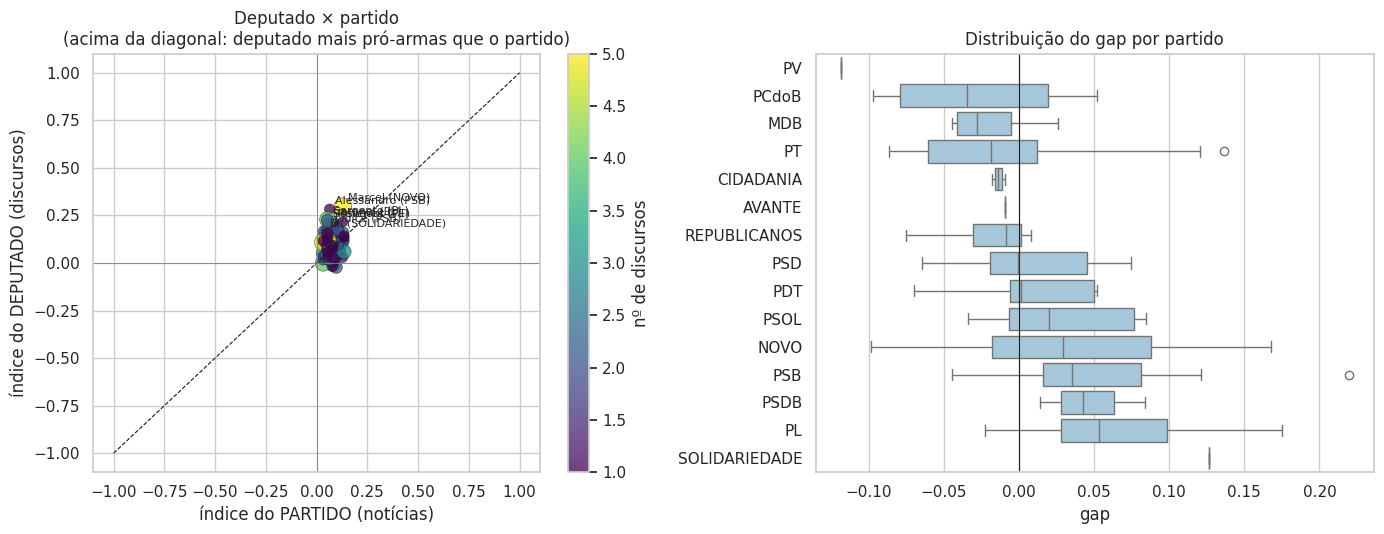

In [25]:
u = units.dropna(subset=["party_index"])
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sc = ax[0].scatter(u.party_index, u.dep_index, c=u.dep_n, s=30 + 25 * u.dep_n, cmap="viridis", alpha=.75, edgecolor="k", lw=.4)
ax[0].plot([-1, 1], [-1, 1], "k--", lw=.8); ax[0].axhline(0, c="gray", lw=.6); ax[0].axvline(0, c="gray", lw=.6)
for _, r in u.sort_values("abs_gap", ascending=False).head(8).iterrows():
    ax[0].annotate(f"{r.deputy_name.split()[0]} ({r.party_n})", (r.party_index, r.dep_index), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[0].set_xlabel("índice do PARTIDO (notícias)"); ax[0].set_ylabel("índice do DEPUTADO (discursos)")
ax[0].set_title("Deputado × partido\n(acima da diagonal: deputado mais pró-armas que o partido)"); plt.colorbar(sc, ax=ax[0], label="nº de discursos")
order = u.groupby("party_n").gap.median().sort_values().index
sns.boxplot(data=u, y="party_n", x="gap", order=order, ax=ax[1], color="#9ecae1"); ax[1].axvline(0, c="k", lw=.8)
ax[1].set_title("Distribuição do gap por partido"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

units.to_csv(OUT_DIR / "deputy_metrics.csv", index=False)

## 8. Etapa 5 — Construindo o rótulo "aderente × não aderente"

### 8.1 O problema: **não existe gabarito**

Os dados não dizem quem é aderente ao partido. Precisamos *definir* o rótulo, e essa definição é a decisão mais importante desta seção. Princípios:

1. **O rótulo não pode ser derivado das mesmas saídas que serão usadas como atributos.** Se definíssemos aderência por "$s_d$ e $s_p$ do Manacá têm o mesmo sinal", o classificador apenas redescobriria essa regra (**circularidade**) e qualquer acurácia seria vazia.
2. Portanto o rótulo usa **somente** a anotação independente `stance` do dataset de discursos (PRO/CON/NEUTRAL), **sem** Manacá e **sem** notícias.

### 8.2 Definição adotada — "linha do plenário"

Para cada par $(d,p)$:

* **posição de referência do deputado**: $r_d$ = média de `stance` (PRO=+1, CON=−1, NEUTRAL=0) nos seus discursos; $\text{pos}_d=\operatorname{sign}(r_d)$ se $|r_d|\ge$ `REF_MIN`, senão neutro (0);
* **linha do partido no plenário**: $L_p^{(-d)}$ = média ponderada de $r$ dos **outros parlamentares** do mesmo partido, **excluindo $d$** (*leave-one-out*, para o deputado não "votar" na própria linha);
* a linha só existe se houver ≥ `MIN_OTHER_UNITS` outros parlamentares e $|L_p^{(-d)}|\ge$ `LINE_MIN`;
* **aderente** se $\text{pos}_d=\operatorname{sign}(L_p^{(-d)})$; **não aderente** caso contrário (oposto, ou neutro se `NEUTRAL_POLICY="non_adherent"`; com `"exclude"` os neutros saem do conjunto).

Assim, a pergunta que o classificador responde é **testável**: *as métricas textuais — posição do partido nas **notícias** e do deputado nos **discursos**, lidas pelo Manacá — conseguem prever se o deputado seguiu a linha que o partido tem no plenário?* Isso também avalia indiretamente se as notícias partidárias representam a posição parlamentar do partido.

> ⚠️ **Limites do rótulo.** (i) "Linha do plenário" mede *coesão da bancada*, não obediência ou punição partidária; (ii) deputados em partidos de posição mista (PDT, PP) têm linha fraca e podem ser excluídos; (iii) o `stance` de referência foi anotado por um processo próprio e também tem erro.

In [26]:
def add_adherence_label(units_df, policy=NEUTRAL_POLICY, min_others=MIN_OTHER_UNITS, line_min=LINE_MIN, ref_min=REF_MIN):
    u = units_df.copy()
    lines = []
    for _, r in u.iterrows():
        o = u[(u.party_n == r.party_n) & (u.deputy_id != r.deputy_id)]
        lines.append(np.average(o.ref_index, weights=o.dep_n) if len(o) >= min_others else np.nan)
    u["plenary_line"] = lines
    u["ref_pos"] = np.where(u.ref_index.abs() >= ref_min, np.sign(u.ref_index), 0)
    u["line_pos"] = np.where(u.plenary_line.abs() >= line_min, np.sign(u.plenary_line), np.nan)
    u["dissent_type"] = np.select([u.line_pos.isna(), u.ref_pos == u.line_pos, u.ref_pos == 0], ["sem linha", "aderente", "neutro"], "oposto")
    y = (u.dissent_type.isin(["oposto", "neutro"])).astype(float)
    y[u.dissent_type == "sem linha"] = np.nan
    if policy == "exclude":
        y[u.dissent_type == "neutro"] = np.nan
    u["nao_aderente"] = y
    return u

units_l = add_adherence_label(units)
print("Distribuição do rótulo (todos os pares deputado×partido):")
display(pd.crosstab(units_l.party_n, units_l.dissent_type, margins=True))
data_ml = units_l.dropna(subset=["nao_aderente", "party_index"]).reset_index(drop=True)
data_ml["nao_aderente"] = data_ml.nao_aderente.astype(int)
print(f"\nConjunto supervisionado: {len(data_ml)} parlamentares | não aderentes = {data_ml.nao_aderente.sum()} ({data_ml.nao_aderente.mean():.1%})")
print(f"Perdidos por falta de notícias do partido ou de linha clara: {len(units_l) - len(data_ml)}")

Distribuição do rótulo (todos os pares deputado×partido):


dissent_type,aderente,neutro,oposto,sem linha,All
party_n,,,,,
AVANTE,0,0,0,1,1
CIDADANIA,0,0,0,2,2
DEM,6,0,0,0,6
MDB,4,0,0,0,4
MISSÃO,0,0,0,1,1
NOVO,4,1,0,0,5
PCdoB,6,0,0,0,6
PDT,1,1,2,1,5
PL,27,0,0,0,27



Conjunto supervisionado: 100 parlamentares | não aderentes = 7 (7.0%)
Perdidos por falta de notícias do partido ou de linha clara: 44


> **Leitura honesta do desbalanceamento.** O comportamento esperado em votações temáticas é alta coesão partidária, portanto os dissidentes são **raros**. Com poucas dezenas ou menos de dissidentes, qualquer classificador tem **poder estatístico muito limitado**. Por isso: (a) usamos métricas adequadas a eventos raros (PR-AUC / *average precision*, balanced accuracy, MCC) em vez de acurácia; (b) comparamos sempre contra baselines triviais; (c) repetimos a validação cruzada 20× para medir **instabilidade**; (d) reportamos o intervalo, não só a média.

## 9. Etapa 6 — Classificadores

### 9.1 Atributos (todos vindos das análises textuais do Manacá)

| Grupo | Atributos | Fonte |
|---|---|---|
| **Deputado** (`DEP`) | `dep_index`, `dep_pfav`, `dep_pcon`, `dep_pneu`, `dep_share_fav`, `dep_share_con`, `dep_conf`, `dep_s_std`, `dep_n` | discursos |
| **Partido** (`PARTY`) | `party_index`, `party_fav_total`, `party_fav_rel`, `party_con_rel`, `party_rel_rate`, `party_n_rel`, `party_sd` | notícias |
| **Alinhamento** (`GAP`) | `gap`, `abs_gap`, `z`, `js`, `align_code` | deputado vs. partido |
| **Metadado** (`META`) | `frac_party_voice` (fração de falas em nome da bancada: liderança, orientação, encaminhamento) | tipo de discurso |

### 9.2 Modelos e baselines

* **Baseline constante**: sempre prevê "aderente" — mostra o piso (PR-AUC = prevalência);
* **Regra de alinhamento**: não aderente quando as posições texto-deputado × texto-partido são **opostas** (`align_code`) — o classificador "ingênuo" que qualquer modelo precisa superar para justificar sua complexidade;
* **Regressão logística** (balanceada, regularizada, padronizada);
* **Random Forest** (rasa, balanceada);
* **Gradient Boosting** (árvores de profundidade 2).

Hiperparâmetros **fixos e conservadores**, sem busca interna: com poucos positivos, selecionar hiperparâmetros por *grid search* aninhado seria instável e geraria o mesmo otimismo que a validação aninhada procura evitar.

### 9.3 Validação

* **`StratifiedGroupKFold` agrupado por `deputy_id`** (o mesmo parlamentar nunca está em treino e teste), `n_splits = min(5, nº de positivos)`, **repetida `N_REPEATS` vezes** com sementes distintas;
* métricas calculadas sobre as predições *out-of-fold* de cada repetição; reportamos média ± desvio entre repetições;
* **teste de estresse "leave-one-party-out"**: o modelo nunca viu o partido do deputado que está sendo previsto. Se o desempenho despencar, o modelo estava memorizando partidos, não aprendendo um padrão de dissidência.

In [27]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, matthews_corrcoef, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FS = {
 "DEP":   ["dep_index", "dep_pfav", "dep_pcon", "dep_pneu", "dep_share_fav", "dep_share_con", "dep_conf", "dep_s_std", "dep_n"],
 "PARTY": ["party_index", "party_fav_total", "party_fav_rel", "party_con_rel", "party_rel_rate", "party_n_rel", "party_sd"],
 "GAP":   ["gap", "abs_gap", "z", "js", "align_code"],
 "META":  ["frac_party_voice"],
}
FEATURE_SETS = {
 "A. só deputado (DEP)":                 FS["DEP"],
 "B. só partido (PARTY)":                FS["PARTY"],
 "C. texto completo (DEP+PARTY+GAP)":    FS["DEP"] + FS["PARTY"] + FS["GAP"],
 "D. texto + metadado (C+META)":         FS["DEP"] + FS["PARTY"] + FS["GAP"] + FS["META"],
}
PRIMARY_FS = "C. texto completo (DEP+PARTY+GAP)"


class ConstantBaseline(BaseEstimator, ClassifierMixin):
    """Piso: sempre prevê 'aderente' (P(não aderente)=0). Probabilidade constante => ROC-AUC=0,5 e PR-AUC=prevalência.
    (Não usamos DummyClassifier(prior): empilhar predições de folds com priors diferentes cria um AUC espúrio.)"""
    def fit(self, X, y): self.classes_ = np.array([0, 1]); return self
    def predict_proba(self, X): n = len(X); return np.c_[np.ones(n), np.zeros(n)]
    def predict(self, X): return np.zeros(len(X), dtype=int)

class AlignmentRule(BaseEstimator, ClassifierMixin):
    """Baseline sem aprendizado: P(não aderente) = 1 se posições opostas, 0,25 se um lado neutro, 0 se alinhado."""
    def __init__(self, col="align_code"): self.col = col
    def fit(self, X, y): self.classes_ = np.array([0, 1]); return self
    def predict_proba(self, X):
        p = np.asarray(X[self.col], float); return np.c_[1 - p, p]
    def predict(self, X): return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

def model_zoo(seed=SEED):
    return {
     "Baseline constante": ConstantBaseline(),
     "Regra de alinhamento": AlignmentRule(),
     "Regressão logística": make_pipeline(StandardScaler(), LogisticRegression(C=0.5, class_weight="balanced", max_iter=5000)),
     "Random Forest":      RandomForestClassifier(n_estimators=300, max_depth=3, min_samples_leaf=3, class_weight="balanced_subsample", random_state=seed, n_jobs=-1),
     "Gradient Boosting":  GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=seed),
    }

def metrics_from_proba(y, p, thr=0.5):
    yhat = (p >= thr).astype(int)
    return dict(PR_AUC=average_precision_score(y, p), ROC_AUC=roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
                bal_acc=balanced_accuracy_score(y, yhat), macroF1=f1_score(y, yhat, average="macro"),
                MCC=matthews_corrcoef(y, yhat), prec_pos=precision_score(y, yhat, zero_division=0), rec_pos=recall_score(y, yhat, zero_division=0))

def repeated_group_cv(df, features, model, n_repeats=N_REPEATS, seed=SEED):
    X, y, g = df[features], df.nao_aderente.values, df.deputy_id.values
    k = int(min(5, y.sum(), len(np.unique(g))))
    if k < 2: raise ValueError("Positivos insuficientes para validação cruzada.")
    res, oofs = [], []
    for r in range(n_repeats):
        oof = np.zeros(len(y))
        for tr, te in StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=seed + r).split(X, y, g):
            m = clone(model).fit(X.iloc[tr], y[tr]); oof[te] = m.predict_proba(X.iloc[te])[:, 1]
        res.append(metrics_from_proba(y, oof)); oofs.append(oof)
    return pd.DataFrame(res), np.mean(oofs, axis=0)

def leave_party_out(df, features, model):
    X, y = df[features], df.nao_aderente.values
    oof = np.full(len(y), np.nan)
    for tr, te in LeaveOneGroupOut().split(X, y, df.party_n.values):
        if y[tr].sum() == 0: continue
        oof[te] = clone(model).fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:, 1]
    ok = ~np.isnan(oof)
    return metrics_from_proba(y[ok], oof[ok]), oof

BASELINES = ("Baseline constante", "Regra de alinhamento")
print(f"positivos = {data_ml.nao_aderente.sum()} | prevalência = {data_ml.nao_aderente.mean():.3f} → PR-AUC do baseline constante = prevalência")

positivos = 7 | prevalência = 0.070 → PR-AUC do baseline constante = prevalência


### 9.4 Resultados principais (conjunto de atributos C: texto completo)

In [28]:
res_rows, oof_store = [], {}
for name, mdl in model_zoo().items():
    r, oof = repeated_group_cv(data_ml, FEATURE_SETS[PRIMARY_FS], mdl)
    oof_store[name] = oof
    row = {"modelo": name}
    for c in r.columns: row[c] = f"{r[c].mean():.3f} ± {r[c].std():.3f}"
    res_rows.append(row)
main_res = pd.DataFrame(res_rows).set_index("modelo")
display(main_res)
print("PR_AUC é a métrica-guia (evento raro). Compare sempre com o baseline constante (= prevalência) e com a Regra de alinhamento.")
main_res.to_csv(OUT_DIR / "classification_main.csv")

,PR_AUC,ROC_AUC,bal_acc,macroF1,MCC,prec_pos,rec_pos
modelo,,,,,,,
Baseline constante,0.070 ± 0.000,0.500 ± 0.000,0.500 ± 0.000,0.482 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
Regra de alinhamento,0.070 ± 0.000,0.500 ± 0.000,0.500 ± 0.000,0.482 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
Regressão logística,0.117 ± 0.038,0.554 ± 0.042,0.546 ± 0.049,0.488 ± 0.027,0.054 ± 0.057,0.093 ± 0.025,0.350 ± 0.086
Random Forest,0.110 ± 0.015,0.653 ± 0.053,0.480 ± 0.007,0.472 ± 0.003,-0.053 ± 0.009,0.000 ± 0.000,0.000 ± 0.000
Gradient Boosting,0.087 ± 0.017,0.532 ± 0.086,0.484 ± 0.008,0.474 ± 0.004,-0.047 ± 0.013,0.000 ± 0.000,0.000 ± 0.000


PR_AUC é a métrica-guia (evento raro). Compare sempre com o baseline constante (= prevalência) e com a Regra de alinhamento.


### 9.5 Ablação: o que cada fonte de informação acrescenta?

Esta é a pergunta que liga o classificador à pergunta de pesquisa. Se o conjunto **B (só partido)** ou **C (texto completo)** não superar **A (só deputado)**, as notícias do partido **não agregam informação** sobre a aderência do deputado além do que o próprio discurso já diz.

modelo,Gradient Boosting,Random Forest,Regressão logística
atributos,,,
A. só deputado (DEP),0.072,0.103,0.067
B. só partido (PARTY),0.338,0.351,0.135
C. texto completo (DEP+PARTY+GAP),0.085,0.107,0.111
D. texto + metadado (C+META),0.075,0.109,0.109


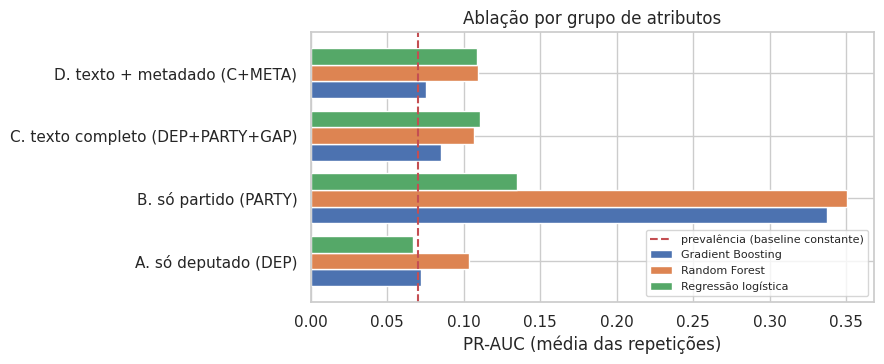

In [29]:
abl_rows = []
for fs_name, feats in FEATURE_SETS.items():
    for mname in ["Regressão logística", "Random Forest", "Gradient Boosting"]:
        r, _ = repeated_group_cv(data_ml, feats, model_zoo()[mname], n_repeats=max(5, N_REPEATS // 2))
        abl_rows.append(dict(atributos=fs_name, modelo=mname, PR_AUC=r.PR_AUC.mean(), PR_AUC_sd=r.PR_AUC.std(), ROC_AUC=r.ROC_AUC.mean(), bal_acc=r.bal_acc.mean(), MCC=r.MCC.mean()))
abl_df = pd.DataFrame(abl_rows)
piv = abl_df.pivot(index="atributos", columns="modelo", values="PR_AUC")
display(piv.round(3))
fig, ax = plt.subplots(figsize=(9, 3.8))
piv.plot.barh(ax=ax, width=.8); ax.axvline(data_ml.nao_aderente.mean(), color="r", ls="--", label="prevalência (baseline constante)")
ax.set_xlabel("PR-AUC (média das repetições)"); ax.set_ylabel(""); ax.legend(fontsize=8, loc="lower right"); ax.set_title("Ablação por grupo de atributos")
plt.tight_layout(); plt.show()
abl_df.to_csv(OUT_DIR / "classification_ablation.csv", index=False)

> ⚠️ **Cuidado ao ler os conjuntos que contêm atributos do partido (B, C, D).** Todos os deputados de um mesmo partido compartilham **exatamente os mesmos** valores de `party_*`. Na validação agrupada por deputado, o modelo pode usar esses atributos como **identificador do partido** e aprender "deputados do partido X costumam ser dissidentes" — memorização, não aprendizado de padrão. Um conjunto B bom **não** prova que as notícias ajudam; só o teste *leave-one-party-out* (9.6) separa as duas hipóteses.

### 9.6 Teste de estresse: *leave-one-party-out*

O modelo prevê deputados de um partido **que ele nunca viu no treino**. É a avaliação mais exigente — e a única que distingue *aprender padrão de dissidência* de *memorizar partidos*. As predições de folds diferentes vêm de modelos diferentes e são empilhadas; AUCs empilhados devem ser lidos com cautela, preferindo PR-AUC e a comparação com os baselines.

In [30]:
lpo_rows = []
for fs_name, feats in FEATURE_SETS.items():
    for name, mdl in model_zoo().items():
        if name in BASELINES and fs_name != PRIMARY_FS: continue     # baselines não dependem dos atributos
        m_, _ = leave_party_out(data_ml, feats, mdl)
        lpo_rows.append({"atributos": fs_name if name not in BASELINES else "—", "modelo": name, **{k: round(v, 3) for k, v in m_.items()}})
lpo_df = pd.DataFrame(lpo_rows)
display(lpo_df.set_index(["atributos", "modelo"]))
print(f"prevalência = {data_ml.nao_aderente.mean():.3f}. Se PR_AUC cair para perto disso (ou abaixo da Regra de alinhamento), o desempenho da ablação vinha de memorizar partidos.")
lpo_df.to_csv(OUT_DIR / "classification_leave_party_out.csv", index=False)

PR_AUC  ROC_AUC  bal_acc  macroF1    MCC  prec_pos  rec_pos
atributos                         modelo                                                                           
A. só deputado (DEP)              Regressão logística    0.062    0.361    0.449    0.412 -0.053     0.053    0.286
                                  Random Forest          0.085    0.394    0.545    0.548  0.096     0.167    0.143
                                  Gradient Boosting      0.054    0.286    0.500    0.482  0.000     0.000    0.000
B. só partido (PARTY)             Regressão logística    0.058    0.297    0.343    0.236 -0.178     0.042    0.429
                                  Random Forest          0.100    0.578    0.500    0.482  0.000     0.000    0.000
                                  Gradient Boosting      0.056    0.270    0.500    0.482  0.000     0.000    0.000
—                                 Baseline constante     0.070    0.500    0.500    0.482  0.000     0.000    0.000
                                  Regra de alinhamento   0.070    0.500    0.500    0.482  0.000     0.000    0.000
C. texto completo (DEP+PARTY+GAP) Regressão logística    0.055    0.286    0.250    0.194 -0.294     0.027    0.286
                                  Random Forest          0.060    0.354    0.495    0.479 -0.028     0.000    0.000
                                  Gradient Boosting      0.045    0.134    0.478    0.471 -0.056     0.000    0.000
D. texto + metadado (C+META)      Regressão logística    0.063    0.356    0.331    0.293 -0.176     0.033    0.286
                                  Random Forest          0.062    0.363    0.500    0.482  0.000     0.000    0.000
                                  Gradient Boosting      0.046    0.167    0.478    0.471 -0.056     0.000    0.000

prevalência = 0.070. Se PR_AUC cair para perto disso (ou abaixo da Regra de alinhamento), o desempenho da ablação vinha de memorizar partidos.


### 9.7 Sensibilidade à política de neutros

Com `"non_adherent"` o deputado neutro (fala procedimental) conta como não aderente; com `"exclude"` só dissidência **explícita** (posição oposta) conta. O segundo cenário é mais conservador e tem **menos positivos**. Se as conclusões mudarem muito entre os dois, o rótulo é frágil.

In [31]:
sens_rows = []
for pol in ["non_adherent", "exclude"]:
    d = add_adherence_label(units, policy=pol).dropna(subset=["nao_aderente", "party_index"]).reset_index(drop=True)
    d["nao_aderente"] = d.nao_aderente.astype(int)
    if d.nao_aderente.sum() < 2: sens_rows.append({"política de neutros": pol, "n": len(d), "positivos": int(d.nao_aderente.sum())}); continue
    for mname in ["Regra de alinhamento", "Regressão logística", "Random Forest"]:
        r, _ = repeated_group_cv(d, FEATURE_SETS[PRIMARY_FS], model_zoo()[mname], n_repeats=10)
        sens_rows.append({"política de neutros": pol, "n": len(d), "positivos": int(d.nao_aderente.sum()), "modelo": mname,
                          "PR_AUC": round(r.PR_AUC.mean(), 3), "prevalência": round(d.nao_aderente.mean(), 3), "bal_acc": round(r.bal_acc.mean(), 3)})
display(pd.DataFrame(sens_rows))

,política de neutros,n,positivos,modelo,PR_AUC,prevalência,bal_acc
0,non_adherent,100,7,Regra de alinhamento,0.070,0.070,0.500
1,non_adherent,100,7,Regressão logística,0.111,0.070,0.543
2,non_adherent,100,7,Random Forest,0.107,0.070,0.482
3,exclude,96,3,Regra de alinhamento,0.031,0.031,0.500
4,exclude,96,3,Regressão logística,0.038,0.031,0.407
5,exclude,96,3,Random Forest,0.098,0.031,0.495


### 9.8 O que o modelo usa? (descritivo)

Importância por permutação (queda em PR-AUC ao embaralhar cada atributo) e coeficientes da regressão logística, ajustados em **todos** os dados. É descrição do modelo, **não** evidência causal nem desempenho fora da amostra.

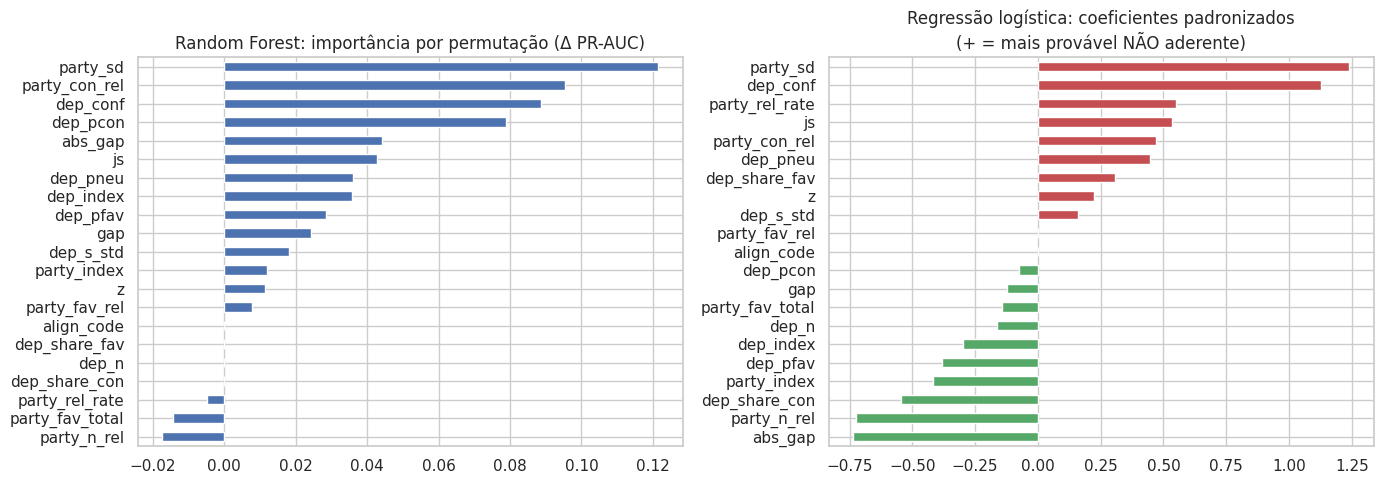

In [32]:
from sklearn.inspection import permutation_importance
feats = FEATURE_SETS[PRIMARY_FS]
Xf, yf = data_ml[feats], data_ml.nao_aderente.values
rf = model_zoo()["Random Forest"].fit(Xf, yf)
pi = permutation_importance(rf, Xf, yf, scoring="average_precision", n_repeats=30, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=feats).sort_values()
lr = model_zoo()["Regressão logística"].fit(Xf, yf)
coef = pd.Series(lr[-1].coef_[0], index=feats).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
imp.plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set_title("Random Forest: importância por permutação (Δ PR-AUC)")
coef.plot.barh(ax=ax[1], color=["#C44E52" if c > 0 else "#55A868" for c in coef]); ax[1].set_title("Regressão logística: coeficientes padronizados\n(+ = mais provável NÃO aderente)")
plt.tight_layout(); plt.show()

### 9.9 Quem são os parlamentares sinalizados?

Probabilidade de **não aderência** *out-of-fold* (média das repetições, melhor modelo por PR-AUC) ao lado do rótulo e das métricas textuais. Casos com rótulo "aderente" mas probabilidade alta merecem leitura qualitativa dos discursos: podem ser erro do Manacá, do rótulo, ou dissidência real que o rótulo não captou.

In [33]:
best_model = max([m for m in oof_store if m not in BASELINES], key=lambda m: average_precision_score(data_ml.nao_aderente, oof_store[m]))
print("modelo usado na listagem:", best_model)
pred_tab = data_ml.assign(p_nao_aderente=oof_store[best_model])[
    ["deputy_name", "party_n", "dep_n", "dissent_type", "nao_aderente", "dep_index", "party_index", "gap", "align_txt", "p_nao_aderente"]]
display(pred_tab.sort_values("p_nao_aderente", ascending=False).head(15).round(3))
pred_tab.to_csv(OUT_DIR / "adherence_predictions.csv", index=False)
data_ml.to_csv(OUT_DIR / "adherence_dataset.csv", index=False)

modelo usado na listagem: Regressão logística


,deputy_name,party_n,dep_n,dissent_type,nao_aderente,dep_index,party_index,gap,align_txt,p_nao_aderente
51,Gilson Marques,NOVO,1,aderente,0,0.216,0.129,0.088,parcial (um lado neutro),0.953
71,Adriana Ventura,NOVO,2,aderente,0,0.158,0.129,0.029,parcial (um lado neutro),0.821
91,Reimont,PT,1,aderente,0,0.216,0.080,0.136,parcial (um lado neutro),0.796
22,Vieira da Cunha,PDT,1,aderente,0,0.077,0.076,0.001,parcial (um lado neutro),0.794
98,Mariana Carvalho,REPUBLICANOS,1,aderente,0,0.143,0.135,0.008,parcial (um lado neutro),0.690
70,Alencar Santana,PT,1,aderente,0,0.092,0.080,0.012,parcial (um lado neutro),0.685
67,Paulo Ganime,NOVO,2,neutro,1,0.111,0.129,-0.018,parcial (um lado neutro),0.683
11,Reginaldo Lopes,PT,1,aderente,0,0.021,0.080,-0.059,parcial (um lado neutro),0.680
24,José Guimarães,PT,1,aderente,0,0.201,0.080,0.121,parcial (um lado neutro),0.677
72,Sâmia Bomfim,PSOL,2,aderente,0,0.030,0.032,-0.003,parcial (um lado neutro),0.651


## 10. Síntese, limitações e próximos passos

### Como ler os resultados

1. **Etapa 1 (relevância)** — a tabela da seção 4.5 mostra quanto do corpus "de armas" era ruído. Confira a qualidade com a validação manual (4.4).
2. **Etapa 2 (postura)** — a validação com o `stance` dos discursos (5.1) dá a medida de confiabilidade do Manacá *no domínio dos discursos*; a validação manual das notícias (5.3) dá a medida *no domínio das notícias*. Se a segunda for bem pior, as métricas partidárias merecem mais cautela que as parlamentares.
3. **Métricas** — o índice com encolhimento e o IC (seção 6) dizem quais partidos têm posição **estimada com segurança**; use a tabela de sensibilidade (6.1) para descartar posições que mudam de sinal.
4. **Classificação** — leia **sempre** contra o baseline constante e a Regra de alinhamento, com o número de positivos em mente. Um modelo que não bate a regra simples não justifica sua complexidade.

### Limitações que não dependem do código

* **Rótulo de aderência construído**, não observado (seção 8). Mede coesão no plenário.
* **Poucos dissidentes**: o poder estatístico do classificador é baixo por natureza do fenômeno, não por falha de método.
* **Tema único (porte de armas) e bills específicos**: a "posição" de um discurso depende do projeto em votação (um projeto pode *restringir* ou *ampliar* o porte). O modelo lê o texto, mas não conhece a proposição.
* **Notícias ≠ posição oficial**: sites partidários publicam também conteúdo republicado e declarações individuais.
* **Modelo de 1,7 B parâmetros, base, sem ajuste fino**: raciocínio limitado (o model card reporta desempenho próximo ao acaso em múltipla escolha). Few-shot + calibração mitigam, não eliminam.
* **Partidos sem notícias** (`PSL`, `DEM`, `PODE`, …) ficam de fora da etapa supervisionada.

### Próximos passos sugeridos

* anotar ~100 notícias e ~100 discursos à mão para medir erro **real** (e, se possível, ajustar o Manacá com *LoRA* nesses rótulos);
* ampliar o corpus de discursos para outros temas (segurança pública, drogas) para ter mais dissidentes;
* incluir votos nominais (se disponíveis) como rótulo de aderência mais objetivo;
* comparar contra um modelo instruído (p. ex. via API) como *sanity check* do Manacá.

### Arquivos gerados em `analysis_outputs_manaca/`

| Arquivo | Conteúdo |
|---|---|
| `news_relevance.csv` | relevância calibrada de cada notícia |
| `speech_stance.csv` | probabilidades de postura de cada discurso |
| `party_metrics.csv` | todas as métricas de favorabilidade por partido |
| `deputy_metrics.csv` | métricas e gaps por parlamentar×partido |
| `adherence_dataset.csv` | conjunto supervisionado (atributos + rótulo) |
| `classification_main.csv`, `classification_ablation.csv` | desempenho dos classificadores |
| `adherence_predictions.csv` | probabilidade de não aderência *out-of-fold* por parlamentar |
| `anotacao_relevancia.csv`, `anotacao_postura.csv` | planilhas para validação manual |

### Referências

* Zhao, Z.; Wallace, E.; Feng, S.; Klein, D.; Singh, S. (2021). *Calibrate Before Use: Improving Few-Shot Performance of Language Models.* ICML.
* Brown, T. et al. (2020). *Language Models are Few-Shot Learners.* NeurIPS.
* Menezes, B. L. S.; Cardoso, C. L. S.; Porto, F. A. M. (2026). *Manacá-1B.* LNCC. Model card: huggingface.co/AIInstituteLNCC/manaca-1b-base.
* Saito, T.; Rehmsmeier, M. (2015). *The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets.* PLoS ONE.